In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================
# 🚀 FINAL PL-LDGAN TRAINING (BALANCED FOR FID/SSIM/LPIPS/NN)
# ============================================================

import os, torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T, models
from torchvision.utils import save_image
from PIL import Image
import torch.nn.functional as F
from tqdm import tqdm

# ================= CONFIG =================
IMG_SIZE = 256
LATENT_CH = 128
BATCH = 12
TIMESTEPS = 150
EPOCHS = 180
LR = 2e-4

# 🔥 Balanced weights
L1 = 0.7   # AE
L2 = 0.05  # KL
L3 = 0.3   # Diffusion
L4 = 0.1   # GAN

DATA_PATH = "/content/drive/MyDrive/POTATODATASET/PLDDATASET/EarlyBlight"

OUT = "/content/drive/MyDrive/POTATODATASET/PLDDATASET/PLDEBOut"
os.makedirs(OUT+"/samples", exist_ok=True)
os.makedirs(OUT+"/ckpt", exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

# ================= DATA =================
class LeafDataset(Dataset):
    def __init__(self, root):
        self.paths = [os.path.join(root,f) for f in os.listdir(root)
                      if f.lower().endswith(('.png','.jpg','.jpeg'))]
        self.tf = T.Compose([
            T.Resize((IMG_SIZE,IMG_SIZE)),
            T.RandomHorizontalFlip(),
            T.RandomRotation(10),
            T.ColorJitter(0.1,0.1,0.1,0.05),
            T.ToTensor(),
            T.Normalize([0.5]*3,[0.5]*3)
        ])
    def __len__(self): return len(self.paths)
    def __getitem__(self,i):
        return self.tf(Image.open(self.paths[i]).convert("RGB"))

loader = DataLoader(
    LeafDataset(DATA_PATH),
    batch_size=BATCH,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

# ================= MODELS =================
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3,64,4,2,1), nn.ReLU(),
            nn.Conv2d(64,128,4,2,1), nn.ReLU(),
            nn.Conv2d(128,LATENT_CH,3,1,1), nn.ReLU()
        )
    def forward(self,x): return self.net(x)

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(LATENT_CH,64,4,2,1),
            nn.ReLU(),
            nn.ConvTranspose2d(64,32,4,2,1),
            nn.ReLU(),
            nn.Conv2d(32,3,3,1,1),
            nn.Tanh()
        )
    def forward(self,z): return self.net(z)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(TIMESTEPS, LATENT_CH)
        self.net = nn.Sequential(
            nn.Conv2d(LATENT_CH,LATENT_CH,3,1,1), nn.ReLU(),
            nn.Conv2d(LATENT_CH,LATENT_CH,3,1,1), nn.ReLU(),
            nn.Conv2d(LATENT_CH,LATENT_CH,3,1,1)
        )
    def forward(self,z,t):
        return self.net(z + self.embed(t).view(-1,LATENT_CH,1,1))

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3,32,4,2,1), nn.LeakyReLU(0.2),
            nn.Conv2d(32,64,4,2,1), nn.LeakyReLU(0.2),
            nn.Conv2d(64,128,4,2,1), nn.LeakyReLU(0.2),
            nn.Conv2d(128,1,4,1,0)
        )
    def forward(self,x): return self.net(x)

# ================= INIT =================
E, G, U, D = Encoder().to(device), Decoder().to(device), UNet().to(device), Discriminator().to(device)

opt_G = optim.Adam(list(E.parameters())+list(G.parameters())+list(U.parameters()), lr=LR)
opt_D = optim.Adam(D.parameters(), lr=LR)

bce = nn.BCEWithLogitsLoss()
scaler = torch.cuda.amp.GradScaler()

# ================= PERCEPTUAL =================
vgg = models.vgg16(pretrained=True).features[:23].to(device).eval()
for p in vgg.parameters(): p.requires_grad=False

def perceptual(x,y):
    return F.l1_loss(vgg((x+1)/2), vgg((y+1)/2))

# ================= DIFFUSION =================
betas = torch.linspace(1e-4,0.02,TIMESTEPS).to(device)
alphas = 1 - betas
alpha_hat = torch.cumprod(alphas,0)

# ================= TRAIN =================
print("🚀 Training FINAL PL-LDGAN")

for epoch in range(EPOCHS):
    for imgs in tqdm(loader):
        imgs = imgs.to(device, non_blocking=True)

        # ===== GENERATOR =====
        with torch.cuda.amp.autocast():
            z = E(imgs)
            recon = G(z)

            L_AE = F.mse_loss(recon, imgs)
            L_KL = torch.mean(z**2)
            L_perc = perceptual(recon, imgs)

            t = torch.randint(0,TIMESTEPS,(z.size(0),),device=device)
            noise = torch.randn_like(z)
            a = alpha_hat[t].view(-1,1,1,1)
            z_t = torch.sqrt(a)*z + torch.sqrt(1-a)*noise

            L_diff = F.mse_loss(U(z_t,t), noise)

            # GAN with smoothing
            real_label = torch.ones_like(D(recon))*0.9
            L_adv = bce(D(recon), real_label)

            L_total = L1*L_AE + L2*L_KL + L3*L_diff + L4*L_adv + 0.2*L_perc

        opt_G.zero_grad()
        scaler.scale(L_total).backward()
        scaler.step(opt_G)

        # ===== DISCRIMINATOR =====
        with torch.cuda.amp.autocast():
            imgs_d = imgs + 0.03*torch.randn_like(imgs)

            pred_real = D(imgs_d)
            pred_fake = D(recon.detach())

            real_label = torch.ones_like(pred_real)*0.9
            fake_label = torch.zeros_like(pred_fake)+0.1

            L_D = 0.5*(bce(pred_real, real_label) +
                       bce(pred_fake, fake_label))

        opt_D.zero_grad()
        scaler.scale(L_D).backward()
        scaler.step(opt_D)

        scaler.update()

    print(f"Epoch {epoch+1} | AE {L_AE:.3f} Diff {L_diff:.3f} GAN {L_adv:.3f}")

    if (epoch+1)%10==0:
        save_image((recon[:8]+1)/2, f"{OUT}/samples/ep{epoch+1}.png")

    if (epoch+1)%20==0:
        torch.save({
            "E":E.state_dict(),
            "G":G.state_dict(),
            "U":U.state_dict(),
            "D":D.state_dict()
        }, f"{OUT}/ckpt/model_{epoch+1}.pt")

In [ ]:
# ============================================================
# 🚀 PL-LDGAN FOLD-1 TRAINING (CLASS-SPECIFIC, NO LEAKAGE)
# ============================================================

import os, torch, numpy as np
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T, models
from torchvision.utils import save_image
from PIL import Image
import torch.nn.functional as F
from sklearn.model_selection import StratifiedKFold
from tqdm import tqdm

# ================= CONFIG =================
ROOT = "/content/drive/MyDrive/POTATODATASET/PLDDATASET"  # root with class folders
TARGET_CLASS_NAME = "EarlyBlight"

IMG_SIZE = 256
LATENT_CH = 128
BATCH = 12
TIMESTEPS = 150
EPOCHS = 100   # reduce for fold training (can increase later)
LR = 2e-4

OUT = "/content/drive/MyDrive/POTATODATASET/PLDDATASET/fold1_output"
os.makedirs(OUT+"/samples", exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

# ================= LOAD DATA =================
def load_paths_labels(root):
    paths, labels = [], []
    classes = sorted(os.listdir(root))

    for idx, cls in enumerate(classes):
        cls_path = os.path.join(root, cls)
        for f in os.listdir(cls_path):
            if f.lower().endswith(('.png','.jpg','.jpeg')):
                paths.append(os.path.join(cls_path, f))
                labels.append(idx)

    return np.array(paths), np.array(labels), classes

ALL_PATHS, ALL_LABELS, CLASS_NAMES = load_paths_labels(ROOT)

# ================= FOLD SPLIT =================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, val_idx = list(skf.split(ALL_PATHS, ALL_LABELS))[0]  # 👉 FIRST FOLD

TARGET_CLASS = CLASS_NAMES.index(TARGET_CLASS_NAME)

train_paths = ALL_PATHS[train_idx]
train_labels = ALL_LABELS[train_idx]

# 👉 ONLY class-specific data for GAN
fold_train_class_paths = train_paths[train_labels == TARGET_CLASS]

print(f"Training GAN for class: {TARGET_CLASS_NAME}")
print(f"Samples in fold-train: {len(fold_train_class_paths)}")

# ================= DATASET =================
class LeafDataset(Dataset):
    def __init__(self, paths):
        self.paths = paths
        self.tf = T.Compose([
            T.Resize((IMG_SIZE,IMG_SIZE)),
            T.RandomHorizontalFlip(),
            T.RandomRotation(10),
            T.ColorJitter(0.1,0.1,0.1,0.05),
            T.ToTensor(),
            T.Normalize([0.5]*3,[0.5]*3)
        ])

    def __len__(self): return len(self.paths)

    def __getitem__(self,i):
        return self.tf(Image.open(self.paths[i]).convert("RGB"))

loader = DataLoader(LeafDataset(fold_train_class_paths),
                    batch_size=BATCH, shuffle=True)

# ================= MODELS =================
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3,64,4,2,1), nn.ReLU(),
            nn.Conv2d(64,128,4,2,1), nn.ReLU(),
            nn.Conv2d(128,LATENT_CH,3,1,1), nn.ReLU()
        )
    def forward(self,x): return self.net(x)

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(LATENT_CH,64,4,2,1),
            nn.ReLU(),
            nn.ConvTranspose2d(64,32,4,2,1),
            nn.ReLU(),
            nn.Conv2d(32,3,3,1,1),
            nn.Tanh()
        )
    def forward(self,z): return self.net(z)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(TIMESTEPS, LATENT_CH)
        self.net = nn.Sequential(
            nn.Conv2d(LATENT_CH,LATENT_CH,3,1,1), nn.ReLU(),
            nn.Conv2d(LATENT_CH,LATENT_CH,3,1,1), nn.ReLU(),
            nn.Conv2d(LATENT_CH,LATENT_CH,3,1,1)
        )
    def forward(self,z,t):
        return self.net(z + self.embed(t).view(-1,LATENT_CH,1,1))

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3,32,4,2,1), nn.LeakyReLU(0.2),
            nn.Conv2d(32,64,4,2,1), nn.LeakyReLU(0.2),
            nn.Conv2d(64,128,4,2,1), nn.LeakyReLU(0.2),
            nn.Conv2d(128,1,4,1,0)
        )
    def forward(self,x): return self.net(x)

E, G, U, D = Encoder().to(device), Decoder().to(device), UNet().to(device), Discriminator().to(device)

opt_G = optim.Adam(list(E.parameters())+list(G.parameters())+list(U.parameters()), lr=LR)
opt_D = optim.Adam(D.parameters(), lr=LR)

bce = nn.BCEWithLogitsLoss()

# ================= TRAIN =================
print("🚀 Training PL-LDGAN (Fold-1, Single Class)")

for epoch in range(EPOCHS):
    for imgs in tqdm(loader):
        imgs = imgs.to(device)

        # ===== GENERATOR =====
        z = E(imgs)
        recon = G(z)

        L_AE = F.mse_loss(recon, imgs)
        L_KL = torch.mean(z**2)

        t = torch.randint(0,TIMESTEPS,(z.size(0),),device=device)
        noise = torch.randn_like(z)
        z_t = z + noise

        L_diff = F.mse_loss(U(z_t,t), noise)

        L_adv = bce(D(recon), torch.ones_like(D(recon))*0.9)

        L_total = L_AE + 0.05*L_KL + 0.3*L_diff + 0.1*L_adv

        opt_G.zero_grad()
        L_total.backward()
        opt_G.step()

        # ===== DISCRIMINATOR =====
        pred_real = D(imgs)
        pred_fake = D(recon.detach())

        L_D = 0.5*(bce(pred_real, torch.ones_like(pred_real)*0.9) +
                   bce(pred_fake, torch.zeros_like(pred_fake)))

        opt_D.zero_grad()
        L_D.backward()
        opt_D.step()

    print(f"Epoch {epoch+1} | AE {L_AE:.3f} Diff {L_diff:.3f}")

    if (epoch+1)%10==0:
        save_image((recon[:8]+1)/2, f"{OUT}/samples/ep{epoch+1}.png")

print("✅ Training Complete")

Training GAN for class: EarlyBlight
Samples in fold-train: 1302
🚀 Training PL-LDGAN (Fold-1, Single Class)


100%|██████████| 109/109 [00:42<00:00,  2.57it/s]


Epoch 1 | AE 0.026 Diff 0.856


100%|██████████| 109/109 [00:15<00:00,  7.01it/s]


Epoch 2 | AE 0.026 Diff 0.743


...

100%|██████████| 109/109 [00:15<00:00,  7.19it/s]


Epoch 41 | AE 0.002 Diff 0.360


100%|██████████| 109/109 [00:15<00:00,  7.25it/s]


Epoch 42 | AE 0.003 Diff 0.359


 77%|███████▋  | 84/109 [00:11<00:03,  7.18it/s]

In [ ]:
# ============================================================
# 🚀 PL-LDGAN FOLD-1 TRAINING (FINAL + NO LEAKAGE)
# ============================================================

import os, torch, numpy as np
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T, models
from torchvision.utils import save_image
from PIL import Image
import torch.nn.functional as F
from sklearn.model_selection import StratifiedKFold
from tqdm import tqdm

# ================= PATH =================
ROOT = "/content/drive/MyDrive/POTATODATASET/PLDDATASET"
OUT = "/content/drive/MyDrive/POTATODATASET/EBFOLD1_PL_LDGAN"

SAMPLE_DIR = os.path.join(OUT, "samples")
CKPT_DIR = os.path.join(OUT, "checkpoints")

os.makedirs(SAMPLE_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

# ================= CONFIG =================
IMG_SIZE = 256
LATENT_CH = 128
BATCH = 8
TIMESTEPS = 200
EPOCHS = 100
LR = 2e-4

device = "cuda" if torch.cuda.is_available() else "cpu"

# ================= LOAD DATA =================
def load_paths_labels(root):
    paths, labels = [], []
    classes = sorted(os.listdir(root))

    for idx, cls in enumerate(classes):
        cls_path = os.path.join(root, cls)
        for f in os.listdir(cls_path):
            if f.lower().endswith(('.png','.jpg','.jpeg')):
                paths.append(os.path.join(cls_path, f))
                labels.append(idx)

    return np.array(paths), np.array(labels), classes

ALL_PATHS, ALL_LABELS, CLASS_NAMES = load_paths_labels(ROOT)

# ================= FOLD-1 =================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, val_idx = list(skf.split(ALL_PATHS, ALL_LABELS))[0]

TARGET_CLASS_NAME = "EarlyBlight"
TARGET_CLASS = CLASS_NAMES.index(TARGET_CLASS_NAME)

train_paths = ALL_PATHS[train_idx]
train_labels = ALL_LABELS[train_idx]

fold_train_paths = train_paths[train_labels == TARGET_CLASS]

print("Training class:", TARGET_CLASS_NAME)
print("Fold-1 samples:", len(fold_train_paths))

# ================= DATASET =================
class LeafDataset(Dataset):
    def __init__(self, paths):
        self.paths = paths
        self.tf = T.Compose([
            T.Resize((IMG_SIZE,IMG_SIZE)),
            T.ToTensor(),
            T.Normalize([0.5]*3,[0.5]*3)
        ])

    def __len__(self): return len(self.paths)

    def __getitem__(self,i):
        return self.tf(Image.open(self.paths[i]).convert("RGB"))

loader = DataLoader(LeafDataset(fold_train_paths),
                    batch_size=BATCH,
                    shuffle=True,
                    num_workers=2,
                    pin_memory=True)

# ================= MODEL =================
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,64,4,2,1)
        self.conv2 = nn.Conv2d(64,128,4,2,1)
        self.conv3 = nn.Conv2d(128,LATENT_CH,3,1,1)

    def forward(self,x):
        x1 = F.relu(self.conv1(x))
        x2 = F.relu(self.conv2(x1))
        z  = F.relu(self.conv3(x2))
        return z, x1, x2

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_latent = nn.Sequential(
            nn.Conv2d(LATENT_CH+128,128,3,1,1),
            nn.BatchNorm2d(128), nn.ReLU()
        )

        self.up1 = nn.ConvTranspose2d(128,64,4,2,1)

        self.conv1 = nn.Sequential(
            nn.Conv2d(64+64,64,3,1,1),
            nn.BatchNorm2d(64), nn.ReLU()
        )

        self.up2 = nn.ConvTranspose2d(64,32,4,2,1)

        self.refine = nn.Sequential(
            nn.Conv2d(32,32,3,1,1),
            nn.ReLU(),
            nn.Conv2d(32,3,3,1,1)
        )

    def forward(self,z,x1,x2):
        x = torch.cat([z,x2],1)
        x = self.conv_latent(x)
        x = self.up1(x)
        x = torch.cat([x,x1],1)
        x = self.conv1(x)
        x = self.up2(x)
        return torch.tanh(self.refine(x))

class LatentUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(TIMESTEPS, LATENT_CH)
        self.net = nn.Sequential(
            nn.Conv2d(LATENT_CH,LATENT_CH,3,1,1), nn.SiLU(),
            nn.Conv2d(LATENT_CH,LATENT_CH,3,1,1), nn.SiLU(),
            nn.Conv2d(LATENT_CH,LATENT_CH,3,1,1)
        )

    def forward(self,z,t):
        e = self.embed(t).view(-1,LATENT_CH,1,1)
        return self.net(z + e)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,32,4,2,1)
        self.conv2 = nn.Conv2d(32,64,4,2,1)
        self.conv3 = nn.Conv2d(64,128,4,2,1)
        self.out = nn.Conv2d(128,1,4,1,0)

    def forward(self,x):
        f1 = F.leaky_relu(self.conv1(x),0.2)
        f2 = F.leaky_relu(self.conv2(f1),0.2)
        f3 = F.leaky_relu(self.conv3(f2),0.2)
        out = self.out(f3)
        return out, [f1,f2,f3]

# ================= INIT =================
E, G, U, D = Encoder().to(device), Decoder().to(device), LatentUNet().to(device), Discriminator().to(device)

opt_G = optim.Adam(list(E.parameters())+list(G.parameters())+list(U.parameters()), lr=LR)
opt_D = optim.Adam(D.parameters(), lr=LR, betas=(0.5,0.999))

bce = nn.BCEWithLogitsLoss()

# ================= PERCEPTUAL =================
vgg = models.vgg16(pretrained=True).features[:23].to(device).eval()
for p in vgg.parameters(): p.requires_grad=False

def perceptual(x,y):
    return F.l1_loss(vgg((x+1)/2), vgg((y+1)/2))

# ================= DIFFUSION =================
betas = torch.linspace(1e-4,0.02,TIMESTEPS).to(device)
alphas = 1 - betas
alpha_hat = torch.cumprod(alphas,0)

# ================= TRAIN =================
print("🚀 Training Fold-1 PL-LDGAN")

for epoch in range(EPOCHS):
    for imgs in tqdm(loader):
        imgs = imgs.to(device)

        z,x1,x2 = E(imgs)
        recon = G(z,x1,x2)

        # ===== LOSSES =====
        ae = F.mse_loss(recon,imgs)
        perc = perceptual(recon,imgs)

        t = torch.randint(0,TIMESTEPS,(z.size(0),),device=device)
        noise = torch.randn_like(z)
        a = alpha_hat[t].view(-1,1,1,1)
        z_noisy = torch.sqrt(a)*z + torch.sqrt(1-a)*noise

        diff = F.mse_loss(U(z_noisy,t), noise)

        pred_fake, feat_fake = D(recon)
        pred_real, feat_real = D(imgs)

        gan = bce(pred_fake, torch.ones_like(pred_fake))

        fm = sum(F.l1_loss(f_fake, f_real.detach()) for f_fake,f_real in zip(feat_fake,feat_real))

        g_loss = 0.8*ae + 0.3*diff + 0.25*gan + 0.25*perc + 0.1*fm

        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()

        # ===== DISCRIMINATOR =====
        d_loss = 0.5*(bce(pred_real, torch.ones_like(pred_real)) +
                      bce(pred_fake.detach(), torch.zeros_like(pred_fake)))

        opt_D.zero_grad()
        d_loss.backward()
        opt_D.step()

    print(f"Epoch {epoch+1} | AE {ae:.3f} Diff {diff:.3f} GAN {gan:.3f}")

    # ===== SAVE SAMPLES =====
    if (epoch+1)%10==0:
        save_image((recon[:8]+1)/2, f"{SAMPLE_DIR}/epoch_{epoch+1}.png", nrow=4)

    # ===== SAVE CHECKPOINT =====
    if (epoch+1)%20==0:
        torch.save({
            "E":E.state_dict(),
            "G":G.state_dict(),
            "U":U.state_dict(),
            "D":D.state_dict()
        }, f"{CKPT_DIR}/model_epoch_{epoch+1}.pt")

print("✅ Training Complete")

Training class: EarlyBlight
Fold-1 samples: 1302


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 227MB/s]


🚀 Training Fold-1 PL-LDGAN


...

Epoch 98 | AE 0.000 Diff 0.223 GAN 0.000


100%|██████████| 163/163 [00:05<00:00, 29.67it/s]


Epoch 99 | AE 0.001 Diff 0.238 GAN 0.000


100%|██████████| 163/163 [00:05<00:00, 29.59it/s]


Epoch 100 | AE 0.000 Diff 0.314 GAN 0.000
✅ Training Complete


In [ ]:
# ============================================================
# 🚀 GENERATE 5000  EARLY BLIGHT IMAGES ( - FOLD1)
# ============================================================

import os, torch, zipfile, random
from torch import nn
from torchvision import transforms as T
from torchvision.utils import save_image
from PIL import Image
from tqdm import tqdm

# ================= PATH =================
CHECKPOINT_PATH = "/content/drive/MyDrive/POTATODATASET/EBFOLD1_PL_LDGAN/checkpoints/model_epoch_100.pt"

# 👉 IMPORTANT: same class folder used in Fold-1 training
DATASET_PATH = "/content/drive/MyDrive/POTATODATASET/PLDDATASET/EarlyBlight"

OUT_DIR = "/content/drive/MyDrive/POTATODATASET/EBFOLD1_PL_LDGAN/generated_5000"
ZIP_PATH = "/content/drive/MyDrive/POTATODATASET/EBFOLD1_PL_LDGAN/generated_5000.zip"

os.makedirs(OUT_DIR, exist_ok=True)

# ================= CONFIG =================
IMG_SIZE = 256
LATENT_CH = 128
TOTAL_IMAGES = 5000
NOISE_STRENGTH = 0.12   # 🔥 best range: 0.1–0.15

device = "cuda" if torch.cuda.is_available() else "cpu"

# ================= TRANSFORM =================
tf = T.Compose([
    T.Resize((IMG_SIZE,IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.5]*3,[0.5]*3)
])

# ================= LOAD IMAGE PATHS =================
img_files = [os.path.join(DATASET_PATH,f)
             for f in os.listdir(DATASET_PATH)
             if f.lower().endswith(('.png','.jpg','.jpeg'))]

print(f"✅ Real images loaded: {len(img_files)}")

# ================= MODEL =================
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,64,4,2,1)
        self.conv2 = nn.Conv2d(64,128,4,2,1)
        self.conv3 = nn.Conv2d(128,LATENT_CH,3,1,1)

    def forward(self,x):
        x1 = torch.relu(self.conv1(x))
        x2 = torch.relu(self.conv2(x1))
        z  = torch.relu(self.conv3(x2))
        return z, x1, x2

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_latent = nn.Sequential(
            nn.Conv2d(LATENT_CH+128,128,3,1,1),
            nn.BatchNorm2d(128), nn.ReLU()
        )

        self.up1 = nn.ConvTranspose2d(128,64,4,2,1)

        self.conv1 = nn.Sequential(
            nn.Conv2d(64+64,64,3,1,1),
            nn.BatchNorm2d(64), nn.ReLU()
        )

        self.up2 = nn.ConvTranspose2d(64,32,4,2,1)

        self.refine = nn.Sequential(
            nn.Conv2d(32,32,3,1,1),
            nn.ReLU(),
            nn.Conv2d(32,3,3,1,1)
        )

    def forward(self,z,x1,x2):
        x = torch.cat([z,x2],1)
        x = self.conv_latent(x)

        x = self.up1(x)
        x = torch.cat([x,x1],1)
        x = self.conv1(x)

        x = self.up2(x)
        return torch.tanh(self.refine(x))

# ================= LOAD MODEL =================
E = Encoder().to(device)
G = Decoder().to(device)

ckpt = torch.load(CHECKPOINT_PATH, map_location=device)

print("Checkpoint keys:", ckpt.keys())

E.load_state_dict(ckpt["E"])
G.load_state_dict(ckpt["G"])

E.eval(); G.eval()
print("✅ Model Loaded")

# ================= GENERATION =================
print("🚀 Generating images...")

for i in tqdm(range(TOTAL_IMAGES)):

    # pick random real image
    img_path = random.choice(img_files)

    img = Image.open(img_path).convert("RGB")
    img = tf(img).unsqueeze(0).to(device)

    with torch.no_grad():
        z,x1,x2 = E(img)

        # 🔥 KEY: latent perturbation
        noise = torch.randn_like(z) * NOISE_STRENGTH
        z = z + noise

        fake = G(z,x1,x2)

    save_image((fake[0]+1)/2,
               f"{OUT_DIR}/img_{i:05d}.png")

print("✅ 5000 images generated")

# ================= ZIP =================
print("📦 Creating ZIP...")

with zipfile.ZipFile(ZIP_PATH,'w',zipfile.ZIP_DEFLATED) as zf:
    for f in os.listdir(OUT_DIR):
        zf.write(os.path.join(OUT_DIR,f), f)

print(f"✅ ZIP saved at: {ZIP_PATH}")

✅ Real images loaded: 1628
Checkpoint keys: dict_keys(['E', 'G', 'U', 'D'])
✅ Model Loaded
🚀 Generating images...


100%|██████████| 5000/5000 [03:54<00:00, 21.35it/s]


✅ 5000 images generated
📦 Creating ZIP...
✅ ZIP saved at: /content/drive/MyDrive/POTATODATASET/EBFOLD1_PL_LDGAN/generated_5000.zip


In [ ]:
# ============================================================
# 🚀 PL-LDGAN FOLD-2 TRAINING (FINAL + NO LEAKAGE)
# ============================================================

import os, torch, numpy as np
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T, models
from torchvision.utils import save_image
from PIL import Image
import torch.nn.functional as F
from sklearn.model_selection import StratifiedKFold
from tqdm import tqdm

# ================= PATH =================
ROOT = "/content/drive/MyDrive/POTATODATASET/PLDDATASET"
OUT = "/content/drive/MyDrive/POTATODATASET/EBFOLD1_PL_LDGAN"

SAMPLE_DIR = os.path.join(OUT, "samples")
CKPT_DIR = os.path.join(OUT, "checkpoints")

os.makedirs(SAMPLE_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

# ================= CONFIG =================
IMG_SIZE = 256
LATENT_CH = 128
BATCH = 8
TIMESTEPS = 200
EPOCHS = 100
LR = 2e-4

device = "cuda" if torch.cuda.is_available() else "cpu"

# ================= LOAD DATA =================
def load_paths_labels(root):
    paths, labels = [], []
    classes = sorted(os.listdir(root))

    for idx, cls in enumerate(classes):
        cls_path = os.path.join(root, cls)
        for f in os.listdir(cls_path):
            if f.lower().endswith(('.png','.jpg','.jpeg')):
                paths.append(os.path.join(cls_path, f))
                labels.append(idx)

    return np.array(paths), np.array(labels), classes

ALL_PATHS, ALL_LABELS, CLASS_NAMES = load_paths_labels(ROOT)

# ================= FOLD-1 =================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, val_idx = list(skf.split(ALL_PATHS, ALL_LABELS))[0]

TARGET_CLASS_NAME = "EarlyBlight"
TARGET_CLASS = CLASS_NAMES.index(TARGET_CLASS_NAME)

train_paths = ALL_PATHS[train_idx]
train_labels = ALL_LABELS[train_idx]

fold_train_paths = train_paths[train_labels == TARGET_CLASS]

print("Training class:", TARGET_CLASS_NAME)
print("Fold-1 samples:", len(fold_train_paths))

# ================= DATASET =================
class LeafDataset(Dataset):
    def __init__(self, paths):
        self.paths = paths
        self.tf = T.Compose([
            T.Resize((IMG_SIZE,IMG_SIZE)),
            T.ToTensor(),
            T.Normalize([0.5]*3,[0.5]*3)
        ])

    def __len__(self): return len(self.paths)

    def __getitem__(self,i):
        return self.tf(Image.open(self.paths[i]).convert("RGB"))

loader = DataLoader(LeafDataset(fold_train_paths),
                    batch_size=BATCH,
                    shuffle=True,
                    num_workers=2,
                    pin_memory=True)

# ================= MODEL =================
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,64,4,2,1)
        self.conv2 = nn.Conv2d(64,128,4,2,1)
        self.conv3 = nn.Conv2d(128,LATENT_CH,3,1,1)

    def forward(self,x):
        x1 = F.relu(self.conv1(x))
        x2 = F.relu(self.conv2(x1))
        z  = F.relu(self.conv3(x2))
        return z, x1, x2

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_latent = nn.Sequential(
            nn.Conv2d(LATENT_CH+128,128,3,1,1),
            nn.BatchNorm2d(128), nn.ReLU()
        )

        self.up1 = nn.ConvTranspose2d(128,64,4,2,1)

        self.conv1 = nn.Sequential(
            nn.Conv2d(64+64,64,3,1,1),
            nn.BatchNorm2d(64), nn.ReLU()
        )

        self.up2 = nn.ConvTranspose2d(64,32,4,2,1)

        self.refine = nn.Sequential(
            nn.Conv2d(32,32,3,1,1),
            nn.ReLU(),
            nn.Conv2d(32,3,3,1,1)
        )

    def forward(self,z,x1,x2):
        x = torch.cat([z,x2],1)
        x = self.conv_latent(x)
        x = self.up1(x)
        x = torch.cat([x,x1],1)
        x = self.conv1(x)
        x = self.up2(x)
        return torch.tanh(self.refine(x))

class LatentUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(TIMESTEPS, LATENT_CH)
        self.net = nn.Sequential(
            nn.Conv2d(LATENT_CH,LATENT_CH,3,1,1), nn.SiLU(),
            nn.Conv2d(LATENT_CH,LATENT_CH,3,1,1), nn.SiLU(),
            nn.Conv2d(LATENT_CH,LATENT_CH,3,1,1)
        )

    def forward(self,z,t):
        e = self.embed(t).view(-1,LATENT_CH,1,1)
        return self.net(z + e)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,32,4,2,1)
        self.conv2 = nn.Conv2d(32,64,4,2,1)
        self.conv3 = nn.Conv2d(64,128,4,2,1)
        self.out = nn.Conv2d(128,1,4,1,0)

    def forward(self,x):
        f1 = F.leaky_relu(self.conv1(x),0.2)
        f2 = F.leaky_relu(self.conv2(f1),0.2)
        f3 = F.leaky_relu(self.conv3(f2),0.2)
        out = self.out(f3)
        return out, [f1,f2,f3]

# ================= INIT =================
E, G, U, D = Encoder().to(device), Decoder().to(device), LatentUNet().to(device), Discriminator().to(device)

opt_G = optim.Adam(list(E.parameters())+list(G.parameters())+list(U.parameters()), lr=LR)
opt_D = optim.Adam(D.parameters(), lr=LR, betas=(0.5,0.999))

bce = nn.BCEWithLogitsLoss()

# ================= PERCEPTUAL =================
vgg = models.vgg16(pretrained=True).features[:23].to(device).eval()
for p in vgg.parameters(): p.requires_grad=False

def perceptual(x,y):
    return F.l1_loss(vgg((x+1)/2), vgg((y+1)/2))

# ================= DIFFUSION =================
betas = torch.linspace(1e-4,0.02,TIMESTEPS).to(device)
alphas = 1 - betas
alpha_hat = torch.cumprod(alphas,0)

# ================= TRAIN =================
print("🚀 Training Fold-1 PL-LDGAN")

for epoch in range(EPOCHS):
    for imgs in tqdm(loader):
        imgs = imgs.to(device)

        z,x1,x2 = E(imgs)
        recon = G(z,x1,x2)

        # ===== LOSSES =====
        ae = F.mse_loss(recon,imgs)
        perc = perceptual(recon,imgs)

        t = torch.randint(0,TIMESTEPS,(z.size(0),),device=device)
        noise = torch.randn_like(z)
        a = alpha_hat[t].view(-1,1,1,1)
        z_noisy = torch.sqrt(a)*z + torch.sqrt(1-a)*noise

        diff = F.mse_loss(U(z_noisy,t), noise)

        pred_fake, feat_fake = D(recon)
        pred_real, feat_real = D(imgs)

        gan = bce(pred_fake, torch.ones_like(pred_fake))

        fm = sum(F.l1_loss(f_fake, f_real.detach()) for f_fake,f_real in zip(feat_fake,feat_real))

        g_loss = 0.8*ae + 0.3*diff + 0.25*gan + 0.25*perc + 0.1*fm

        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()

        # ===== DISCRIMINATOR =====
        d_loss = 0.5*(bce(pred_real, torch.ones_like(pred_real)) +
                      bce(pred_fake.detach(), torch.zeros_like(pred_fake)))

        opt_D.zero_grad()
        d_loss.backward()
        opt_D.step()

    print(f"Epoch {epoch+1} | AE {ae:.3f} Diff {diff:.3f} GAN {gan:.3f}")

    # ===== SAVE SAMPLES =====
    if (epoch+1)%10==0:
        save_image((recon[:8]+1)/2, f"{SAMPLE_DIR}/epoch_{epoch+1}.png", nrow=4)

    # ===== SAVE CHECKPOINT =====
    if (epoch+1)%20==0:
        torch.save({
            "E":E.state_dict(),
            "G":G.state_dict(),
            "U":U.state_dict(),
            "D":D.state_dict()
        }, f"{CKPT_DIR}/model_epoch_{epoch+1}.pt")

print("✅ Training Complete")

In [ ]:
# ============================================================
# 🚀 PL-LDGAN FOLD-2 TRAINING (FINAL + NO LEAKAGE)
# ============================================================

import os, torch, numpy as np
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T, models
from torchvision.utils import save_image
from PIL import Image
import torch.nn.functional as F
from sklearn.model_selection import StratifiedKFold
from tqdm import tqdm

# ================= PATH =================
ROOT = "/content/drive/MyDrive/POTATODATASET/PLDDATASET"
OUT = "/content/drive/MyDrive/POTATODATASET/EBFOLD2_PL_LDGAN"

SAMPLE_DIR = os.path.join(OUT, "samples")
CKPT_DIR = os.path.join(OUT, "checkpoints")

os.makedirs(SAMPLE_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

# ================= CONFIG =================
IMG_SIZE = 256
LATENT_CH = 128
BATCH = 8
TIMESTEPS = 200
EPOCHS = 100
LR = 2e-4

device = "cuda" if torch.cuda.is_available() else "cpu"

# ================= LOAD DATA =================
def load_paths_labels(root):
    paths, labels = [], []
    classes = sorted(os.listdir(root))

    for idx, cls in enumerate(classes):
        cls_path = os.path.join(root, cls)
        for f in os.listdir(cls_path):
            if f.lower().endswith(('.png','.jpg','.jpeg')):
                paths.append(os.path.join(cls_path, f))
                labels.append(idx)

    return np.array(paths), np.array(labels), classes

ALL_PATHS, ALL_LABELS, CLASS_NAMES = load_paths_labels(ROOT)

# ================= FOLD-2 =================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 👉 Fold-2 (INDEX = 1)
train_idx, val_idx = list(skf.split(ALL_PATHS, ALL_LABELS))[1]

TARGET_CLASS_NAME = "EarlyBlight"
TARGET_CLASS = CLASS_NAMES.index(TARGET_CLASS_NAME)

train_paths = ALL_PATHS[train_idx]
train_labels = ALL_LABELS[train_idx]

fold_train_paths = train_paths[train_labels == TARGET_CLASS]

print("Training class:", TARGET_CLASS_NAME)
print("Fold-2 samples:", len(fold_train_paths))

# ================= DATASET =================
class LeafDataset(Dataset):
    def __init__(self, paths):
        self.paths = paths
        self.tf = T.Compose([
            T.Resize((IMG_SIZE, IMG_SIZE)),
            T.ToTensor(),
            T.Normalize([0.5]*3, [0.5]*3)
        ])

    def __len__(self): return len(self.paths)

    def __getitem__(self, i):
        return self.tf(Image.open(self.paths[i]).convert("RGB"))

loader = DataLoader(
    LeafDataset(fold_train_paths),
    batch_size=BATCH,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

# ================= MODEL =================
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,64,4,2,1)
        self.conv2 = nn.Conv2d(64,128,4,2,1)
        self.conv3 = nn.Conv2d(128,LATENT_CH,3,1,1)

    def forward(self,x):
        x1 = F.relu(self.conv1(x))
        x2 = F.relu(self.conv2(x1))
        z  = F.relu(self.conv3(x2))
        return z, x1, x2

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_latent = nn.Sequential(
            nn.Conv2d(LATENT_CH+128,128,3,1,1),
            nn.BatchNorm2d(128), nn.ReLU()
        )

        self.up1 = nn.ConvTranspose2d(128,64,4,2,1)

        self.conv1 = nn.Sequential(
            nn.Conv2d(64+64,64,3,1,1),
            nn.BatchNorm2d(64), nn.ReLU()
        )

        self.up2 = nn.ConvTranspose2d(64,32,4,2,1)

        self.refine = nn.Sequential(
            nn.Conv2d(32,32,3,1,1),
            nn.ReLU(),
            nn.Conv2d(32,3,3,1,1)
        )

    def forward(self,z,x1,x2):
        x = torch.cat([z,x2],1)
        x = self.conv_latent(x)
        x = self.up1(x)
        x = torch.cat([x,x1],1)
        x = self.conv1(x)
        x = self.up2(x)
        return torch.tanh(self.refine(x))

class LatentUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(TIMESTEPS, LATENT_CH)
        self.net = nn.Sequential(
            nn.Conv2d(LATENT_CH,LATENT_CH,3,1,1), nn.SiLU(),
            nn.Conv2d(LATENT_CH,LATENT_CH,3,1,1), nn.SiLU(),
            nn.Conv2d(LATENT_CH,LATENT_CH,3,1,1)
        )

    def forward(self,z,t):
        e = self.embed(t).view(-1,LATENT_CH,1,1)
        return self.net(z + e)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,32,4,2,1)
        self.conv2 = nn.Conv2d(32,64,4,2,1)
        self.conv3 = nn.Conv2d(64,128,4,2,1)
        self.out = nn.Conv2d(128,1,4,1,0)

    def forward(self,x):
        f1 = F.leaky_relu(self.conv1(x),0.2)
        f2 = F.leaky_relu(self.conv2(f1),0.2)
        f3 = F.leaky_relu(self.conv3(f2),0.2)
        out = self.out(f3)
        return out, [f1,f2,f3]

# ================= INIT =================
E, G, U, D = Encoder().to(device), Decoder().to(device), LatentUNet().to(device), Discriminator().to(device)

opt_G = optim.Adam(list(E.parameters())+list(G.parameters())+list(U.parameters()), lr=LR)
opt_D = optim.Adam(D.parameters(), lr=LR, betas=(0.5,0.999))

bce = nn.BCEWithLogitsLoss()

# ================= PERCEPTUAL =================
vgg = models.vgg16(pretrained=True).features[:23].to(device).eval()
for p in vgg.parameters(): p.requires_grad=False

def perceptual(x,y):
    return F.l1_loss(vgg((x+1)/2), vgg((y+1)/2))

# ================= DIFFUSION =================
betas = torch.linspace(1e-4,0.02,TIMESTEPS).to(device)
alphas = 1 - betas
alpha_hat = torch.cumprod(alphas,0)

# ================= TRAIN =================
print("🚀 Training Fold-2 PL-LDGAN")

for epoch in range(EPOCHS):
    for imgs in tqdm(loader):
        imgs = imgs.to(device)

        z,x1,x2 = E(imgs)
        recon = G(z,x1,x2)

        # ===== LOSSES =====
        ae = F.mse_loss(recon,imgs)
        perc = perceptual(recon,imgs)

        t = torch.randint(0,TIMESTEPS,(z.size(0),),device=device)
        noise = torch.randn_like(z)
        a = alpha_hat[t].view(-1,1,1,1)
        z_noisy = torch.sqrt(a)*z + torch.sqrt(1-a)*noise

        diff = F.mse_loss(U(z_noisy,t), noise)

        pred_fake, feat_fake = D(recon)
        pred_real, feat_real = D(imgs)

        gan = bce(pred_fake, torch.ones_like(pred_fake))

        fm = sum(F.l1_loss(f_fake, f_real.detach()) for f_fake,f_real in zip(feat_fake,feat_real))

        g_loss = 0.8*ae + 0.3*diff + 0.25*gan + 0.25*perc + 0.1*fm

        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()

        # ===== DISCRIMINATOR =====
        d_loss = 0.5*(bce(pred_real, torch.ones_like(pred_real)) +
                      bce(pred_fake.detach(), torch.zeros_like(pred_fake)))

        opt_D.zero_grad()
        d_loss.backward()
        opt_D.step()

    print(f"Epoch {epoch+1} | AE {ae:.3f} Diff {diff:.3f} GAN {gan:.3f}")

    # ===== SAVE SAMPLES =====
    if (epoch+1)%10==0:
        save_image((recon[:8]+1)/2, f"{SAMPLE_DIR}/epoch_{epoch+1}.png", nrow=4)

    # ===== SAVE CHECKPOINT =====
    if (epoch+1)%20==0:
        torch.save({
            "E":E.state_dict(),
            "G":G.state_dict(),
            "U":U.state_dict(),
            "D":D.state_dict()
        }, f"{CKPT_DIR}/model_epoch_{epoch+1}.pt")

print("✅ Training Complete")

Training class: EarlyBlight
Fold-2 samples: 1302


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


🚀 Training Fold-2 PL-LDGAN


100%|██████████| 163/163 [00:14<00:00, 11.40it/s]


Epoch 1 | AE 0.005 Diff 0.861 GAN 0.000


...

Epoch 98 | AE 0.000 Diff 0.112 GAN 0.000


100%|██████████| 163/163 [00:05<00:00, 29.56it/s]


Epoch 99 | AE 0.001 Diff 0.172 GAN 0.000


100%|██████████| 163/163 [00:05<00:00, 29.55it/s]


Epoch 100 | AE 0.001 Diff 0.167 GAN 0.000
✅ Training Complete


In [ ]:
# ============================================================
# 🚀 PL-LDGAN FOLD-3 TRAINING (FINAL + NO LEAKAGE)
# ============================================================

import os, torch, numpy as np
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T, models
from torchvision.utils import save_image
from PIL import Image
import torch.nn.functional as F
from sklearn.model_selection import StratifiedKFold
from tqdm import tqdm

# ================= PATH =================
ROOT = "/content/drive/MyDrive/POTATODATASET/PLDDATASET"
OUT = "/content/drive/MyDrive/POTATODATASET/EBFOLD3_PL_LDGAN"

SAMPLE_DIR = os.path.join(OUT, "samples")
CKPT_DIR = os.path.join(OUT, "checkpoints")

os.makedirs(SAMPLE_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

# ================= CONFIG =================
IMG_SIZE = 256
LATENT_CH = 128
BATCH = 8
TIMESTEPS = 200
EPOCHS = 100
LR = 2e-4

device = "cuda" if torch.cuda.is_available() else "cpu"

# ================= LOAD DATA =================
def load_paths_labels(root):
    paths, labels = [], []
    classes = sorted(os.listdir(root))

    for idx, cls in enumerate(classes):
        cls_path = os.path.join(root, cls)
        for f in os.listdir(cls_path):
            if f.lower().endswith(('.png','.jpg','.jpeg')):
                paths.append(os.path.join(cls_path, f))
                labels.append(idx)

    return np.array(paths), np.array(labels), classes

ALL_PATHS, ALL_LABELS, CLASS_NAMES = load_paths_labels(ROOT)

# ================= FOLD-3 =================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 👉 Fold-3 (INDEX = 2)
train_idx, val_idx = list(skf.split(ALL_PATHS, ALL_LABELS))[2]

TARGET_CLASS_NAME = "EarlyBlight"
TARGET_CLASS = CLASS_NAMES.index(TARGET_CLASS_NAME)

train_paths = ALL_PATHS[train_idx]
train_labels = ALL_LABELS[train_idx]

fold_train_paths = train_paths[train_labels == TARGET_CLASS]

print("Training class:", TARGET_CLASS_NAME)
print("Fold-3 samples:", len(fold_train_paths))

# ================= DATASET =================
class LeafDataset(Dataset):
    def __init__(self, paths):
        self.paths = paths
        self.tf = T.Compose([
            T.Resize((IMG_SIZE, IMG_SIZE)),
            T.ToTensor(),
            T.Normalize([0.5]*3, [0.5]*3)
        ])

    def __len__(self): return len(self.paths)

    def __getitem__(self, i):
        return self.tf(Image.open(self.paths[i]).convert("RGB"))

loader = DataLoader(
    LeafDataset(fold_train_paths),
    batch_size=BATCH,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

# ================= MODEL =================
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,64,4,2,1)
        self.conv2 = nn.Conv2d(64,128,4,2,1)
        self.conv3 = nn.Conv2d(128,LATENT_CH,3,1,1)

    def forward(self,x):
        x1 = F.relu(self.conv1(x))
        x2 = F.relu(self.conv2(x1))
        z  = F.relu(self.conv3(x2))
        return z, x1, x2

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_latent = nn.Sequential(
            nn.Conv2d(LATENT_CH+128,128,3,1,1),
            nn.BatchNorm2d(128), nn.ReLU()
        )

        self.up1 = nn.ConvTranspose2d(128,64,4,2,1)

        self.conv1 = nn.Sequential(
            nn.Conv2d(64+64,64,3,1,1),
            nn.BatchNorm2d(64), nn.ReLU()
        )

        self.up2 = nn.ConvTranspose2d(64,32,4,2,1)

        self.refine = nn.Sequential(
            nn.Conv2d(32,32,3,1,1),
            nn.ReLU(),
            nn.Conv2d(32,3,3,1,1)
        )

    def forward(self,z,x1,x2):
        x = torch.cat([z,x2],1)
        x = self.conv_latent(x)
        x = self.up1(x)
        x = torch.cat([x,x1],1)
        x = self.conv1(x)
        x = self.up2(x)
        return torch.tanh(self.refine(x))

class LatentUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(TIMESTEPS, LATENT_CH)
        self.net = nn.Sequential(
            nn.Conv2d(LATENT_CH,LATENT_CH,3,1,1), nn.SiLU(),
            nn.Conv2d(LATENT_CH,LATENT_CH,3,1,1), nn.SiLU(),
            nn.Conv2d(LATENT_CH,LATENT_CH,3,1,1)
        )

    def forward(self,z,t):
        e = self.embed(t).view(-1,LATENT_CH,1,1)
        return self.net(z + e)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,32,4,2,1)
        self.conv2 = nn.Conv2d(32,64,4,2,1)
        self.conv3 = nn.Conv2d(64,128,4,2,1)
        self.out = nn.Conv2d(128,1,4,1,0)

    def forward(self,x):
        f1 = F.leaky_relu(self.conv1(x),0.2)
        f2 = F.leaky_relu(self.conv2(f1),0.2)
        f3 = F.leaky_relu(self.conv3(f2),0.2)
        out = self.out(f3)
        return out, [f1,f2,f3]

# ================= INIT =================
E, G, U, D = Encoder().to(device), Decoder().to(device), LatentUNet().to(device), Discriminator().to(device)

opt_G = optim.Adam(list(E.parameters())+list(G.parameters())+list(U.parameters()), lr=LR)
opt_D = optim.Adam(D.parameters(), lr=LR, betas=(0.5,0.999))

bce = nn.BCEWithLogitsLoss()

# ================= PERCEPTUAL =================
vgg = models.vgg16(pretrained=True).features[:23].to(device).eval()
for p in vgg.parameters(): p.requires_grad=False

def perceptual(x,y):
    return F.l1_loss(vgg((x+1)/2), vgg((y+1)/2))

# ================= DIFFUSION =================
betas = torch.linspace(1e-4,0.02,TIMESTEPS).to(device)
alphas = 1 - betas
alpha_hat = torch.cumprod(alphas,0)

# ================= TRAIN =================
print("🚀 Training Fold-3 PL-LDGAN")

for epoch in range(EPOCHS):
    for imgs in tqdm(loader):
        imgs = imgs.to(device)

        z,x1,x2 = E(imgs)
        recon = G(z,x1,x2)

        # ===== LOSSES =====
        ae = F.mse_loss(recon,imgs)
        perc = perceptual(recon,imgs)

        t = torch.randint(0,TIMESTEPS,(z.size(0),),device=device)
        noise = torch.randn_like(z)
        a = alpha_hat[t].view(-1,1,1,1)
        z_noisy = torch.sqrt(a)*z + torch.sqrt(1-a)*noise

        diff = F.mse_loss(U(z_noisy,t), noise)

        pred_fake, feat_fake = D(recon)
        pred_real, feat_real = D(imgs)

        gan = bce(pred_fake, torch.ones_like(pred_fake))

        fm = sum(F.l1_loss(f_fake, f_real.detach()) for f_fake,f_real in zip(feat_fake,feat_real))

        g_loss = 0.8*ae + 0.3*diff + 0.25*gan + 0.25*perc + 0.1*fm

        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()

        # ===== DISCRIMINATOR =====
        d_loss = 0.5*(bce(pred_real, torch.ones_like(pred_real)) +
                      bce(pred_fake.detach(), torch.zeros_like(pred_fake)))

        opt_D.zero_grad()
        d_loss.backward()
        opt_D.step()

    print(f"Epoch {epoch+1} | AE {ae:.3f} Diff {diff:.3f} GAN {gan:.3f}")

    # ===== SAVE SAMPLES =====
    if (epoch+1)%10==0:
        save_image((recon[:8]+1)/2, f"{SAMPLE_DIR}/epoch_{epoch+1}.png", nrow=4)

    # ===== SAVE CHECKPOINT =====
    if (epoch+1)%20==0:
        torch.save({
            "E":E.state_dict(),
            "G":G.state_dict(),
            "U":U.state_dict(),
            "D":D.state_dict()
        }, f"{CKPT_DIR}/model_epoch_{epoch+1}.pt")

print("✅ Training Complete")

In [ ]:
# ============================================================
# 🚀 PL-LDGAN FOLD-4 TRAINING (FINAL + NO LEAKAGE)
# ============================================================

import os, torch, numpy as np
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T, models
from torchvision.utils import save_image
from PIL import Image
import torch.nn.functional as F
from sklearn.model_selection import StratifiedKFold
from tqdm import tqdm

# ================= PATH =================
ROOT = "/content/drive/MyDrive/POTATODATASET/PLDDATASET"
OUT = "/content/drive/MyDrive/POTATODATASET/EBFOLD4_PL_LDGAN"

SAMPLE_DIR = os.path.join(OUT, "samples")
CKPT_DIR = os.path.join(OUT, "checkpoints")

os.makedirs(SAMPLE_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

# ================= CONFIG =================
IMG_SIZE = 256
LATENT_CH = 128
BATCH = 8
TIMESTEPS = 200
EPOCHS = 100
LR = 2e-4

device = "cuda" if torch.cuda.is_available() else "cpu"

# ================= LOAD DATA =================
def load_paths_labels(root):
    paths, labels = [], []
    classes = sorted(os.listdir(root))

    for idx, cls in enumerate(classes):
        cls_path = os.path.join(root, cls)
        for f in os.listdir(cls_path):
            if f.lower().endswith(('.png','.jpg','.jpeg')):
                paths.append(os.path.join(cls_path, f))
                labels.append(idx)

    return np.array(paths), np.array(labels), classes

ALL_PATHS, ALL_LABELS, CLASS_NAMES = load_paths_labels(ROOT)

# ================= FOLD-4 =================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 👉 Fold-4 (INDEX = 3)
train_idx, val_idx = list(skf.split(ALL_PATHS, ALL_LABELS))[3]

TARGET_CLASS_NAME = "EarlyBlight"
TARGET_CLASS = CLASS_NAMES.index(TARGET_CLASS_NAME)

train_paths = ALL_PATHS[train_idx]
train_labels = ALL_LABELS[train_idx]

fold_train_paths = train_paths[train_labels == TARGET_CLASS]

print("Training class:", TARGET_CLASS_NAME)
print("Fold-4 samples:", len(fold_train_paths))

# ================= DATASET =================
class LeafDataset(Dataset):
    def __init__(self, paths):
        self.paths = paths
        self.tf = T.Compose([
            T.Resize((IMG_SIZE, IMG_SIZE)),
            T.ToTensor(),
            T.Normalize([0.5]*3, [0.5]*3)
        ])

    def __len__(self): return len(self.paths)

    def __getitem__(self, i):
        return self.tf(Image.open(self.paths[i]).convert("RGB"))

loader = DataLoader(
    LeafDataset(fold_train_paths),
    batch_size=BATCH,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

# ================= MODEL =================
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,64,4,2,1)
        self.conv2 = nn.Conv2d(64,128,4,2,1)
        self.conv3 = nn.Conv2d(128,LATENT_CH,3,1,1)

    def forward(self,x):
        x1 = F.relu(self.conv1(x))
        x2 = F.relu(self.conv2(x1))
        z  = F.relu(self.conv3(x2))
        return z, x1, x2

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_latent = nn.Sequential(
            nn.Conv2d(LATENT_CH+128,128,3,1,1),
            nn.BatchNorm2d(128), nn.ReLU()
        )

        self.up1 = nn.ConvTranspose2d(128,64,4,2,1)

        self.conv1 = nn.Sequential(
            nn.Conv2d(64+64,64,3,1,1),
            nn.BatchNorm2d(64), nn.ReLU()
        )

        self.up2 = nn.ConvTranspose2d(64,32,4,2,1)

        self.refine = nn.Sequential(
            nn.Conv2d(32,32,3,1,1),
            nn.ReLU(),
            nn.Conv2d(32,3,3,1,1)
        )

    def forward(self,z,x1,x2):
        x = torch.cat([z,x2],1)
        x = self.conv_latent(x)
        x = self.up1(x)
        x = torch.cat([x,x1],1)
        x = self.conv1(x)
        x = self.up2(x)
        return torch.tanh(self.refine(x))

class LatentUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(TIMESTEPS, LATENT_CH)
        self.net = nn.Sequential(
            nn.Conv2d(LATENT_CH,LATENT_CH,3,1,1), nn.SiLU(),
            nn.Conv2d(LATENT_CH,LATENT_CH,3,1,1), nn.SiLU(),
            nn.Conv2d(LATENT_CH,LATENT_CH,3,1,1)
        )

    def forward(self,z,t):
        e = self.embed(t).view(-1,LATENT_CH,1,1)
        return self.net(z + e)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,32,4,2,1)
        self.conv2 = nn.Conv2d(32,64,4,2,1)
        self.conv3 = nn.Conv2d(64,128,4,2,1)
        self.out = nn.Conv2d(128,1,4,1,0)

    def forward(self,x):
        f1 = F.leaky_relu(self.conv1(x),0.2)
        f2 = F.leaky_relu(self.conv2(f1),0.2)
        f3 = F.leaky_relu(self.conv3(f2),0.2)
        out = self.out(f3)
        return out, [f1,f2,f3]

# ================= INIT =================
E, G, U, D = Encoder().to(device), Decoder().to(device), LatentUNet().to(device), Discriminator().to(device)

opt_G = optim.Adam(list(E.parameters())+list(G.parameters())+list(U.parameters()), lr=LR)
opt_D = optim.Adam(D.parameters(), lr=LR, betas=(0.5,0.999))

bce = nn.BCEWithLogitsLoss()

# ================= PERCEPTUAL =================
vgg = models.vgg16(pretrained=True).features[:23].to(device).eval()
for p in vgg.parameters(): p.requires_grad=False

def perceptual(x,y):
    return F.l1_loss(vgg((x+1)/2), vgg((y+1)/2))

# ================= DIFFUSION =================
betas = torch.linspace(1e-4,0.02,TIMESTEPS).to(device)
alphas = 1 - betas
alpha_hat = torch.cumprod(alphas,0)

# ================= TRAIN =================
print("🚀 Training Fold-4 PL-LDGAN")

for epoch in range(EPOCHS):
    for imgs in tqdm(loader):
        imgs = imgs.to(device)

        z,x1,x2 = E(imgs)
        recon = G(z,x1,x2)

        # ===== LOSSES =====
        ae = F.mse_loss(recon,imgs)
        perc = perceptual(recon,imgs)

        t = torch.randint(0,TIMESTEPS,(z.size(0),),device=device)
        noise = torch.randn_like(z)
        a = alpha_hat[t].view(-1,1,1,1)
        z_noisy = torch.sqrt(a)*z + torch.sqrt(1-a)*noise

        diff = F.mse_loss(U(z_noisy,t), noise)

        pred_fake, feat_fake = D(recon)
        pred_real, feat_real = D(imgs)

        gan = bce(pred_fake, torch.ones_like(pred_fake))

        fm = sum(F.l1_loss(f_fake, f_real.detach()) for f_fake,f_real in zip(feat_fake,feat_real))

        g_loss = 0.8*ae + 0.3*diff + 0.25*gan + 0.25*perc + 0.1*fm

        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()

        # ===== DISCRIMINATOR =====
        d_loss = 0.5*(bce(pred_real, torch.ones_like(pred_real)) +
                      bce(pred_fake.detach(), torch.zeros_like(pred_fake)))

        opt_D.zero_grad()
        d_loss.backward()
        opt_D.step()

    print(f"Epoch {epoch+1} | AE {ae:.3f} Diff {diff:.3f} GAN {gan:.3f}")

    # ===== SAVE SAMPLES =====
    if (epoch+1)%10==0:
        save_image((recon[:8]+1)/2, f"{SAMPLE_DIR}/epoch_{epoch+1}.png", nrow=4)

    # ===== SAVE CHECKPOINT =====
    if (epoch+1)%20==0:
        torch.save({
            "E":E.state_dict(),
            "G":G.state_dict(),
            "U":U.state_dict(),
            "D":D.state_dict()
        }, f"{CKPT_DIR}/model_epoch_{epoch+1}.pt")

print("✅ Training Complete")

In [ ]:
# ============================================================
# 🚀 PL-LDGAN FOLD-5 TRAINING (FINAL + NO LEAKAGE)
# ============================================================

import os, torch, numpy as np
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T, models
from torchvision.utils import save_image
from PIL import Image
import torch.nn.functional as F
from sklearn.model_selection import StratifiedKFold
from tqdm import tqdm

# ================= PATH =================
ROOT = "/content/drive/MyDrive/POTATODATASET/PLDDATASET"
OUT = "/content/drive/MyDrive/POTATODATASET/EBFOLD5_PL_LDGAN"

SAMPLE_DIR = os.path.join(OUT, "samples")
CKPT_DIR = os.path.join(OUT, "checkpoints")

os.makedirs(SAMPLE_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

# ================= CONFIG =================
IMG_SIZE = 256
LATENT_CH = 128
BATCH = 8
TIMESTEPS = 200
EPOCHS = 100
LR = 2e-4

device = "cuda" if torch.cuda.is_available() else "cpu"

# ================= LOAD DATA =================
def load_paths_labels(root):
    paths, labels = [], []
    classes = sorted(os.listdir(root))

    for idx, cls in enumerate(classes):
        cls_path = os.path.join(root, cls)
        for f in os.listdir(cls_path):
            if f.lower().endswith(('.png','.jpg','.jpeg')):
                paths.append(os.path.join(cls_path, f))
                labels.append(idx)

    return np.array(paths), np.array(labels), classes

ALL_PATHS, ALL_LABELS, CLASS_NAMES = load_paths_labels(ROOT)

# ================= FOLD-5 =================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 👉 Fold-5 (INDEX = 4)
train_idx, val_idx = list(skf.split(ALL_PATHS, ALL_LABELS))[4]

TARGET_CLASS_NAME = "EarlyBlight"
TARGET_CLASS = CLASS_NAMES.index(TARGET_CLASS_NAME)

train_paths = ALL_PATHS[train_idx]
train_labels = ALL_LABELS[train_idx]

fold_train_paths = train_paths[train_labels == TARGET_CLASS]

print("Training class:", TARGET_CLASS_NAME)
print("Fold-5 samples:", len(fold_train_paths))

# ================= DATASET =================
class LeafDataset(Dataset):
    def __init__(self, paths):
        self.paths = paths
        self.tf = T.Compose([
            T.Resize((IMG_SIZE, IMG_SIZE)),
            T.ToTensor(),
            T.Normalize([0.5]*3, [0.5]*3)
        ])

    def __len__(self): return len(self.paths)

    def __getitem__(self, i):
        return self.tf(Image.open(self.paths[i]).convert("RGB"))

loader = DataLoader(
    LeafDataset(fold_train_paths),
    batch_size=BATCH,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

# ================= MODEL =================
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,64,4,2,1)
        self.conv2 = nn.Conv2d(64,128,4,2,1)
        self.conv3 = nn.Conv2d(128,LATENT_CH,3,1,1)

    def forward(self,x):
        x1 = F.relu(self.conv1(x))
        x2 = F.relu(self.conv2(x1))
        z  = F.relu(self.conv3(x2))
        return z, x1, x2

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_latent = nn.Sequential(
            nn.Conv2d(LATENT_CH+128,128,3,1,1),
            nn.BatchNorm2d(128), nn.ReLU()
        )

        self.up1 = nn.ConvTranspose2d(128,64,4,2,1)

        self.conv1 = nn.Sequential(
            nn.Conv2d(64+64,64,3,1,1),
            nn.BatchNorm2d(64), nn.ReLU()
        )

        self.up2 = nn.ConvTranspose2d(64,32,4,2,1)

        self.refine = nn.Sequential(
            nn.Conv2d(32,32,3,1,1),
            nn.ReLU(),
            nn.Conv2d(32,3,3,1,1)
        )

    def forward(self,z,x1,x2):
        x = torch.cat([z,x2],1)
        x = self.conv_latent(x)
        x = self.up1(x)
        x = torch.cat([x,x1],1)
        x = self.conv1(x)
        x = self.up2(x)
        return torch.tanh(self.refine(x))

class LatentUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(TIMESTEPS, LATENT_CH)
        self.net = nn.Sequential(
            nn.Conv2d(LATENT_CH,LATENT_CH,3,1,1), nn.SiLU(),
            nn.Conv2d(LATENT_CH,LATENT_CH,3,1,1), nn.SiLU(),
            nn.Conv2d(LATENT_CH,LATENT_CH,3,1,1)
        )

    def forward(self,z,t):
        e = self.embed(t).view(-1,LATENT_CH,1,1)
        return self.net(z + e)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,32,4,2,1)
        self.conv2 = nn.Conv2d(32,64,4,2,1)
        self.conv3 = nn.Conv2d(64,128,4,2,1)
        self.out = nn.Conv2d(128,1,4,1,0)

    def forward(self,x):
        f1 = F.leaky_relu(self.conv1(x),0.2)
        f2 = F.leaky_relu(self.conv2(f1),0.2)
        f3 = F.leaky_relu(self.conv3(f2),0.2)
        out = self.out(f3)
        return out, [f1,f2,f3]

# ================= INIT =================
E, G, U, D = Encoder().to(device), Decoder().to(device), LatentUNet().to(device), Discriminator().to(device)

opt_G = optim.Adam(list(E.parameters())+list(G.parameters())+list(U.parameters()), lr=LR)
opt_D = optim.Adam(D.parameters(), lr=LR, betas=(0.5,0.999))

bce = nn.BCEWithLogitsLoss()

# ================= PERCEPTUAL =================
vgg = models.vgg16(pretrained=True).features[:23].to(device).eval()
for p in vgg.parameters(): p.requires_grad=False

def perceptual(x,y):
    return F.l1_loss(vgg((x+1)/2), vgg((y+1)/2))

# ================= DIFFUSION =================
betas = torch.linspace(1e-4,0.02,TIMESTEPS).to(device)
alphas = 1 - betas
alpha_hat = torch.cumprod(alphas,0)

# ================= TRAIN =================
print("🚀 Training Fold-5 PL-LDGAN")

for epoch in range(EPOCHS):
    for imgs in tqdm(loader):
        imgs = imgs.to(device)

        z,x1,x2 = E(imgs)
        recon = G(z,x1,x2)

        # ===== LOSSES =====
        ae = F.mse_loss(recon,imgs)
        perc = perceptual(recon,imgs)

        t = torch.randint(0,TIMESTEPS,(z.size(0),),device=device)
        noise = torch.randn_like(z)
        a = alpha_hat[t].view(-1,1,1,1)
        z_noisy = torch.sqrt(a)*z + torch.sqrt(1-a)*noise

        diff = F.mse_loss(U(z_noisy,t), noise)

        pred_fake, feat_fake = D(recon)
        pred_real, feat_real = D(imgs)

        gan = bce(pred_fake, torch.ones_like(pred_fake))

        fm = sum(F.l1_loss(f_fake, f_real.detach()) for f_fake,f_real in zip(feat_fake,feat_real))

        g_loss = 0.8*ae + 0.3*diff + 0.25*gan + 0.25*perc + 0.1*fm

        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()

        # ===== DISCRIMINATOR =====
        d_loss = 0.5*(bce(pred_real, torch.ones_like(pred_real)) +
                      bce(pred_fake.detach(), torch.zeros_like(pred_fake)))

        opt_D.zero_grad()
        d_loss.backward()
        opt_D.step()

    print(f"Epoch {epoch+1} | AE {ae:.3f} Diff {diff:.3f} GAN {gan:.3f}")

    # ===== SAVE SAMPLES =====
    if (epoch+1)%10==0:
        save_image((recon[:8]+1)/2, f"{SAMPLE_DIR}/epoch_{epoch+1}.png", nrow=4)

    # ===== SAVE CHECKPOINT =====
    if (epoch+1)%20==0:
        torch.save({
            "E":E.state_dict(),
            "G":G.state_dict(),
            "U":U.state_dict(),
            "D":D.state_dict()
        }, f"{CKPT_DIR}/model_epoch_{epoch+1}.pt")

print("✅ Training Complete")

In [ ]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 91.3 MB/s eta 0:00:00


Real: 1628
Generated: 2000


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


🚀 Extracting features...


100%|██████████| 63/63 [00:13<00:00,  4.60it/s]


🚀 Feature NN (safe)...


100%|██████████| 2000/2000 [21:04<00:00,  1.58it/s]


🚀 Pixel NN (safe)...


100%|██████████| 2000/2000 [06:37<00:00,  5.03it/s]


🚀 Gen-Gen diversity...

📊 ===== FINAL RESULTS =====
Pixel Mean: 1.9558662
Feature Mean: 27.181667
Gen-Gen Mean: 427.15524

Variance -> Real: 0.70572674 | Gen: 0.69875824
ICV -> Real: 302.9612 | Gen: 301.51642
🚀 Running t-SNE...

✅ SAFE + OPTIMIZED VALIDATION COMPLETE


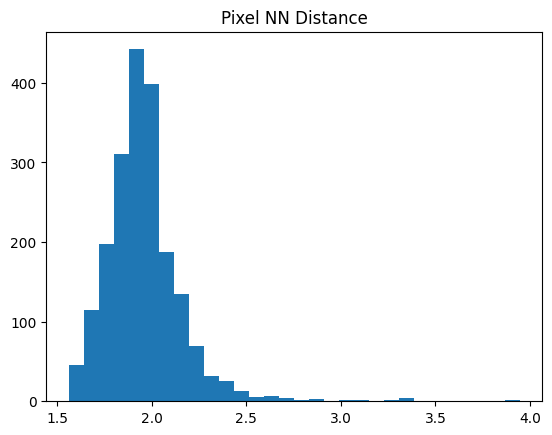

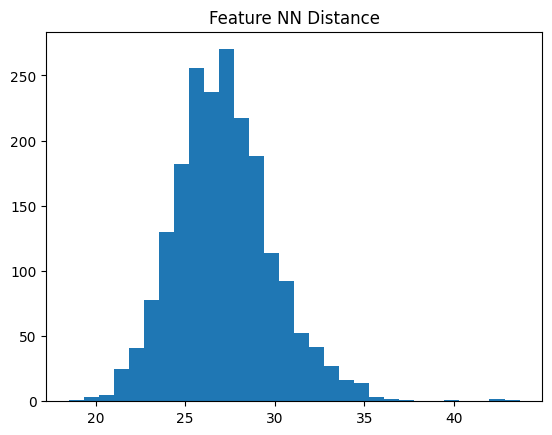

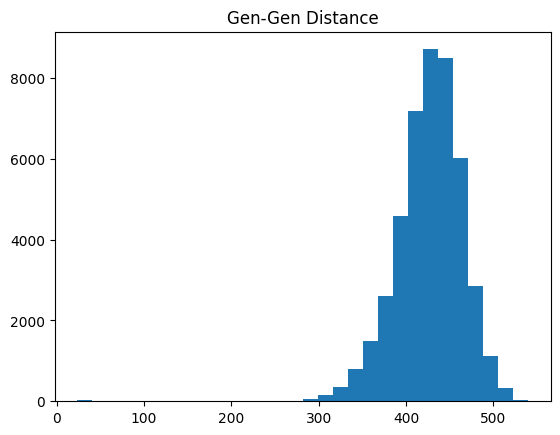

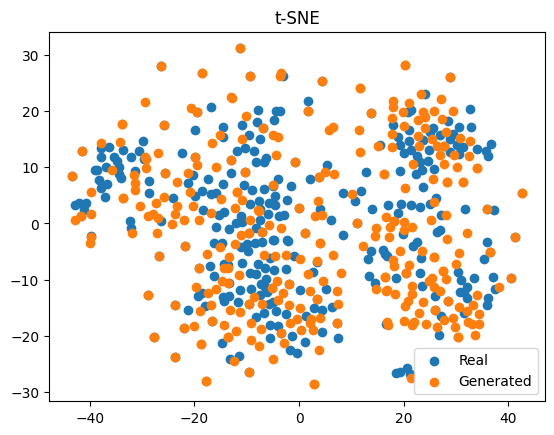

In [ ]:
# ============================================================
# 🚀 FINAL MEMORY-SAFE + OPTIMIZED DIVERSITY VALIDATION
# ============================================================

import os, torch, numpy as np, matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from torchvision import transforms as T, models
from sklearn.manifold import TSNE

# ================= PATHS =================
REAL_DIR = "/content/drive/MyDrive/POTATODATASET/PLDDATASET/EarlyBlight"
GEN_DIR  = "/content/drive/MyDrive/POTATODATASET/EBFOLD1_PL_LDGAN/generated_5000"

device = "cuda" if torch.cuda.is_available() else "cpu"

# ================= TRANSFORM =================
IMG_SIZE = 128   # 🔥 reduced for memory safety
tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor()
])

# ================= LOAD =================
def load_images(folder):
    return [os.path.join(folder,f) for f in os.listdir(folder)
            if f.lower().endswith(('.png','.jpg','.jpeg'))]

real_paths = load_images(REAL_DIR)
gen_paths  = load_images(GEN_DIR)

# 👉 Optional (recommended for speed)
gen_paths  = gen_paths[:2000]
real_paths = real_paths[:2000]

print("Real:", len(real_paths))
print("Generated:", len(gen_paths))

# ============================================================
# 🚀 FEATURE EXTRACTOR (BATCHED)
# ============================================================

vgg = models.vgg16(pretrained=True).features[:23].to(device).eval()
for p in vgg.parameters(): p.requires_grad=False

def extract_features(paths, batch_size=32):
    feats = []
    for i in tqdm(range(0, len(paths), batch_size)):
        imgs = []
        for p in paths[i:i+batch_size]:
            imgs.append(tf(Image.open(p).convert("RGB")))

        imgs = torch.stack(imgs).to(device)

        with torch.no_grad():
            f = vgg(imgs).view(imgs.size(0), -1)

        feats.append(f.cpu().numpy())

    return np.vstack(feats).astype(np.float32)

print("🚀 Extracting features...")
real_feats = extract_features(real_paths)
gen_feats  = extract_features(gen_paths)

# ============================================================
# 🚀 FEATURE NN (SAFE)
# ============================================================

print("🚀 Feature NN (safe)...")

feature_nn = []

for g in tqdm(gen_feats):
    d = np.linalg.norm(real_feats - g, axis=1)
    feature_nn.append(d.min())

feature_nn = np.array(feature_nn)

# ============================================================
# 🚀 PIXEL NN (SAFE, NO MATRIX)
# ============================================================

print("🚀 Pixel NN (safe)...")

def get_pixel(img_path):
    return tf(Image.open(img_path).convert("RGB")).view(-1).numpy()

# Preload real pixels once
real_pixels = np.array([get_pixel(p) for p in tqdm(real_paths)])

pixel_nn = []

for g_path in tqdm(gen_paths):
    g = get_pixel(g_path)
    d = np.linalg.norm(real_pixels - g, axis=1)
    pixel_nn.append(d.min())

pixel_nn = np.array(pixel_nn)

# ============================================================
# 🚀 GEN-GEN DIVERSITY (SUBSET ONLY)
# ============================================================

print("🚀 Gen-Gen diversity...")

subset = min(300, len(gen_feats))
idx = np.random.choice(len(gen_feats), subset, replace=False)

sub = gen_feats[idx]

gen_gen_dist = []

for i in range(subset):
    d = np.linalg.norm(sub - sub[i], axis=1)
    gen_gen_dist.extend(d[i+1:])

gen_gen_dist = np.array(gen_gen_dist)

# ============================================================
# 🚀 VARIANCE + ICV
# ============================================================

real_var = np.var(real_feats, axis=0).mean()
gen_var  = np.var(gen_feats, axis=0).mean()

def icv(feats):
    c = feats.mean(axis=0)
    return np.mean(np.linalg.norm(feats - c, axis=1))

real_icv = icv(real_feats)
gen_icv  = icv(gen_feats)

# ============================================================
# 🚀 RESULTS
# ============================================================

print("\n📊 ===== FINAL RESULTS =====")
print("Pixel Mean:", pixel_nn.mean())
print("Feature Mean:", feature_nn.mean())
print("Gen-Gen Mean:", gen_gen_dist.mean())

print("\nVariance -> Real:", real_var, "| Gen:", gen_var)
print("ICV -> Real:", real_icv, "| Gen:", gen_icv)

# ============================================================
# 🚀 PLOTS
# ============================================================

plt.figure()
plt.hist(pixel_nn, bins=30)
plt.title("Pixel NN Distance")
plt.savefig("pixel_hist.png")

plt.figure()
plt.hist(feature_nn, bins=30)
plt.title("Feature NN Distance")
plt.savefig("feature_hist.png")

plt.figure()
plt.hist(gen_gen_dist, bins=30)
plt.title("Gen-Gen Distance")
plt.savefig("gengen_hist.png")

# ============================================================
# 🚀 t-SNE
# ============================================================

print("🚀 Running t-SNE...")

sample_n = min(300, len(real_feats), len(gen_feats))

combined = np.vstack([real_feats[:sample_n], gen_feats[:sample_n]])

tsne = TSNE(n_components=2, random_state=42)
emb = tsne.fit_transform(combined)

plt.figure()
plt.scatter(emb[:sample_n,0], emb[:sample_n,1], label="Real")
plt.scatter(emb[sample_n:,0], emb[sample_n:,1], label="Generated")
plt.legend()
plt.title("t-SNE")
plt.savefig("tsne.png")

print("\n✅ SAFE + OPTIMIZED VALIDATION COMPLETE")

In [ ]:
# ============================================================
# 🚀 PL-LDGAN FOLD-1 TRAINING HEALTHY (FINAL + NO LEAKAGE)
# ============================================================

import os, torch, numpy as np
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T, models
from torchvision.utils import save_image
from PIL import Image
import torch.nn.functional as F
from sklearn.model_selection import StratifiedKFold
from tqdm import tqdm

# ================= PATH =================
ROOT = "/content/drive/MyDrive/POTATODATASET/PLDDATASET"
OUT = "/content/drive/MyDrive/POTATODATASET/HealthyFOLD1_PL_LDGAN"

SAMPLE_DIR = os.path.join(OUT, "samples")
CKPT_DIR = os.path.join(OUT, "checkpoints")

os.makedirs(SAMPLE_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

# ================= CONFIG =================
IMG_SIZE = 256
LATENT_CH = 128
BATCH = 8
TIMESTEPS = 200
EPOCHS = 100
LR = 2e-4

device = "cuda" if torch.cuda.is_available() else "cpu"

# ================= LOAD DATA =================
def load_paths_labels(root):
    paths, labels = [], []
    classes = sorted(os.listdir(root))

    for idx, cls in enumerate(classes):
        cls_path = os.path.join(root, cls)
        for f in os.listdir(cls_path):
            if f.lower().endswith(('.png','.jpg','.jpeg')):
                paths.append(os.path.join(cls_path, f))
                labels.append(idx)

    return np.array(paths), np.array(labels), classes

ALL_PATHS, ALL_LABELS, CLASS_NAMES = load_paths_labels(ROOT)

# ================= FOLD-1 =================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, val_idx = list(skf.split(ALL_PATHS, ALL_LABELS))[0]

TARGET_CLASS_NAME = "Healthy"
TARGET_CLASS = CLASS_NAMES.index(TARGET_CLASS_NAME)

train_paths = ALL_PATHS[train_idx]
train_labels = ALL_LABELS[train_idx]

fold_train_paths = train_paths[train_labels == TARGET_CLASS]

print("Training class:", TARGET_CLASS_NAME)
print("Fold-1 samples:", len(fold_train_paths))

# ================= DATASET =================
class LeafDataset(Dataset):
    def __init__(self, paths):
        self.paths = paths
        self.tf = T.Compose([
            T.Resize((IMG_SIZE,IMG_SIZE)),
            T.ToTensor(),
            T.Normalize([0.5]*3,[0.5]*3)
        ])

    def __len__(self): return len(self.paths)

    def __getitem__(self,i):
        return self.tf(Image.open(self.paths[i]).convert("RGB"))

loader = DataLoader(LeafDataset(fold_train_paths),
                    batch_size=BATCH,
                    shuffle=True,
                    num_workers=2,
                    pin_memory=True)

# ================= MODEL =================
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,64,4,2,1)
        self.conv2 = nn.Conv2d(64,128,4,2,1)
        self.conv3 = nn.Conv2d(128,LATENT_CH,3,1,1)

    def forward(self,x):
        x1 = F.relu(self.conv1(x))
        x2 = F.relu(self.conv2(x1))
        z  = F.relu(self.conv3(x2))
        return z, x1, x2

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_latent = nn.Sequential(
            nn.Conv2d(LATENT_CH+128,128,3,1,1),
            nn.BatchNorm2d(128), nn.ReLU()
        )

        self.up1 = nn.ConvTranspose2d(128,64,4,2,1)

        self.conv1 = nn.Sequential(
            nn.Conv2d(64+64,64,3,1,1),
            nn.BatchNorm2d(64), nn.ReLU()
        )

        self.up2 = nn.ConvTranspose2d(64,32,4,2,1)

        self.refine = nn.Sequential(
            nn.Conv2d(32,32,3,1,1),
            nn.ReLU(),
            nn.Conv2d(32,3,3,1,1)
        )

    def forward(self,z,x1,x2):
        x = torch.cat([z,x2],1)
        x = self.conv_latent(x)
        x = self.up1(x)
        x = torch.cat([x,x1],1)
        x = self.conv1(x)
        x = self.up2(x)
        return torch.tanh(self.refine(x))

class LatentUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(TIMESTEPS, LATENT_CH)
        self.net = nn.Sequential(
            nn.Conv2d(LATENT_CH,LATENT_CH,3,1,1), nn.SiLU(),
            nn.Conv2d(LATENT_CH,LATENT_CH,3,1,1), nn.SiLU(),
            nn.Conv2d(LATENT_CH,LATENT_CH,3,1,1)
        )

    def forward(self,z,t):
        e = self.embed(t).view(-1,LATENT_CH,1,1)
        return self.net(z + e)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,32,4,2,1)
        self.conv2 = nn.Conv2d(32,64,4,2,1)
        self.conv3 = nn.Conv2d(64,128,4,2,1)
        self.out = nn.Conv2d(128,1,4,1,0)

    def forward(self,x):
        f1 = F.leaky_relu(self.conv1(x),0.2)
        f2 = F.leaky_relu(self.conv2(f1),0.2)
        f3 = F.leaky_relu(self.conv3(f2),0.2)
        out = self.out(f3)
        return out, [f1,f2,f3]

# ================= INIT =================
E, G, U, D = Encoder().to(device), Decoder().to(device), LatentUNet().to(device), Discriminator().to(device)

opt_G = optim.Adam(list(E.parameters())+list(G.parameters())+list(U.parameters()), lr=LR)
opt_D = optim.Adam(D.parameters(), lr=LR, betas=(0.5,0.999))

bce = nn.BCEWithLogitsLoss()

# ================= PERCEPTUAL =================
vgg = models.vgg16(pretrained=True).features[:23].to(device).eval()
for p in vgg.parameters(): p.requires_grad=False

def perceptual(x,y):
    return F.l1_loss(vgg((x+1)/2), vgg((y+1)/2))

# ================= DIFFUSION =================
betas = torch.linspace(1e-4,0.02,TIMESTEPS).to(device)
alphas = 1 - betas
alpha_hat = torch.cumprod(alphas,0)

# ================= TRAIN =================
print("🚀 Training Fold-1 PL-LDGAN")

for epoch in range(EPOCHS):
    for imgs in tqdm(loader):
        imgs = imgs.to(device)

        z,x1,x2 = E(imgs)
        recon = G(z,x1,x2)

        # ===== LOSSES =====
        ae = F.mse_loss(recon,imgs)
        perc = perceptual(recon,imgs)

        t = torch.randint(0,TIMESTEPS,(z.size(0),),device=device)
        noise = torch.randn_like(z)
        a = alpha_hat[t].view(-1,1,1,1)
        z_noisy = torch.sqrt(a)*z + torch.sqrt(1-a)*noise

        diff = F.mse_loss(U(z_noisy,t), noise)

        pred_fake, feat_fake = D(recon)
        pred_real, feat_real = D(imgs)

        gan = bce(pred_fake, torch.ones_like(pred_fake))

        fm = sum(F.l1_loss(f_fake, f_real.detach()) for f_fake,f_real in zip(feat_fake,feat_real))

        g_loss = 0.8*ae + 0.3*diff + 0.25*gan + 0.25*perc + 0.1*fm

        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()

        # ===== DISCRIMINATOR =====
        d_loss = 0.5*(bce(pred_real, torch.ones_like(pred_real)) +
                      bce(pred_fake.detach(), torch.zeros_like(pred_fake)))

        opt_D.zero_grad()
        d_loss.backward()
        opt_D.step()

    print(f"Epoch {epoch+1} | AE {ae:.3f} Diff {diff:.3f} GAN {gan:.3f}")

    # ===== SAVE SAMPLES =====
    if (epoch+1)%10==0:
        save_image((recon[:8]+1)/2, f"{SAMPLE_DIR}/epoch_{epoch+1}.png", nrow=4)

    # ===== SAVE CHECKPOINT =====
    if (epoch+1)%20==0:
        torch.save({
            "E":E.state_dict(),
            "G":G.state_dict(),
            "U":U.state_dict(),
            "D":D.state_dict()
        }, f"{CKPT_DIR}/model_epoch_{epoch+1}.pt")

print("✅ Training Complete")

Training class: Healthy
Fold-1 samples: 816


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 242MB/s]


🚀 Training Fold-1 PL-LDGAN


...

Epoch 98 | AE 0.000 Diff 0.171 GAN 0.000


100%|██████████| 102/102 [00:03<00:00, 29.31it/s]


Epoch 99 | AE 0.000 Diff 0.157 GAN 0.000


100%|██████████| 102/102 [00:03<00:00, 29.29it/s]


Epoch 100 | AE 0.001 Diff 0.292 GAN 0.000
✅ Training Complete


In [2]:
# ============================================================
# 🚀 GENERATE 5000  HEALTHY IMAGES ( - FOLD1)
# ============================================================

import os, torch, zipfile, random
from torch import nn
from torchvision import transforms as T
from torchvision.utils import save_image
from PIL import Image
from tqdm import tqdm

# ================= PATH =================
CHECKPOINT_PATH = "/content/drive/MyDrive/POTATODATASET/HealthyFOLD1_PL_LDGAN/checkpoints/model_epoch_100.pt"

# 👉 IMPORTANT: same class folder used in Fold-1 training
DATASET_PATH = "/content/drive/MyDrive/POTATODATASET/PLDDATASET/Healthy"

OUT_DIR = "/content/drive/MyDrive/POTATODATASET/HealthyFOLD1_PL_LDGAN/generated_5000"
ZIP_PATH = "/content/drive/MyDrive/POTATODATASET/HealthyFOLD1_PL_LDGAN/generated_5000.zip"

os.makedirs(OUT_DIR, exist_ok=True)

# ================= CONFIG =================
IMG_SIZE = 256
LATENT_CH = 128
TOTAL_IMAGES = 5000
NOISE_STRENGTH = 0.12   # 🔥 best range: 0.1–0.15

device = "cuda" if torch.cuda.is_available() else "cpu"

# ================= TRANSFORM =================
tf = T.Compose([
    T.Resize((IMG_SIZE,IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.5]*3,[0.5]*3)
])

# ================= LOAD IMAGE PATHS =================
img_files = [os.path.join(DATASET_PATH,f)
             for f in os.listdir(DATASET_PATH)
             if f.lower().endswith(('.png','.jpg','.jpeg'))]

print(f"✅ Real images loaded: {len(img_files)}")

# ================= MODEL =================
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,64,4,2,1)
        self.conv2 = nn.Conv2d(64,128,4,2,1)
        self.conv3 = nn.Conv2d(128,LATENT_CH,3,1,1)

    def forward(self,x):
        x1 = torch.relu(self.conv1(x))
        x2 = torch.relu(self.conv2(x1))
        z  = torch.relu(self.conv3(x2))
        return z, x1, x2

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_latent = nn.Sequential(
            nn.Conv2d(LATENT_CH+128,128,3,1,1),
            nn.BatchNorm2d(128), nn.ReLU()
        )

        self.up1 = nn.ConvTranspose2d(128,64,4,2,1)

        self.conv1 = nn.Sequential(
            nn.Conv2d(64+64,64,3,1,1),
            nn.BatchNorm2d(64), nn.ReLU()
        )

        self.up2 = nn.ConvTranspose2d(64,32,4,2,1)

        self.refine = nn.Sequential(
            nn.Conv2d(32,32,3,1,1),
            nn.ReLU(),
            nn.Conv2d(32,3,3,1,1)
        )

    def forward(self,z,x1,x2):
        x = torch.cat([z,x2],1)
        x = self.conv_latent(x)

        x = self.up1(x)
        x = torch.cat([x,x1],1)
        x = self.conv1(x)

        x = self.up2(x)
        return torch.tanh(self.refine(x))

# ================= LOAD MODEL =================
E = Encoder().to(device)
G = Decoder().to(device)

ckpt = torch.load(CHECKPOINT_PATH, map_location=device)

print("Checkpoint keys:", ckpt.keys())

E.load_state_dict(ckpt["E"])
G.load_state_dict(ckpt["G"])

E.eval(); G.eval()
print("✅ Model Loaded")

# ================= GENERATION =================
print("🚀 Generating images...")

for i in tqdm(range(TOTAL_IMAGES)):

    # pick random real image
    img_path = random.choice(img_files)

    img = Image.open(img_path).convert("RGB")
    img = tf(img).unsqueeze(0).to(device)

    with torch.no_grad():
        z,x1,x2 = E(img)

        # 🔥 KEY: latent perturbation
        noise = torch.randn_like(z) * NOISE_STRENGTH
        z = z + noise

        fake = G(z,x1,x2)

    save_image((fake[0]+1)/2,
               f"{OUT_DIR}/img_{i:05d}.png")

print("✅ 5000 images generated")

# ================= ZIP =================
print("📦 Creating ZIP...")

with zipfile.ZipFile(ZIP_PATH,'w',zipfile.ZIP_DEFLATED) as zf:
    for f in os.listdir(OUT_DIR):
        zf.write(os.path.join(OUT_DIR,f), f)

print(f"✅ ZIP saved at: {ZIP_PATH}")

✅ Real images loaded: 1020
Checkpoint keys: dict_keys(['E', 'G', 'U', 'D'])
✅ Model Loaded
🚀 Generating images...


100%|██████████| 5000/5000 [03:59<00:00, 20.88it/s]


✅ 5000 images generated
📦 Creating ZIP...
✅ ZIP saved at: /content/drive/MyDrive/POTATODATASET/HealthyFOLD1_PL_LDGAN/generated_5000.zip


Real: 1020
Generated: 2000
🚀 Extracting features...


100%|██████████| 63/63 [11:21<00:00, 10.82s/it]


🚀 Feature NN (safe)...


100%|██████████| 2000/2000 [10:43<00:00,  3.11it/s]


🚀 Pixel NN (safe)...


100%|██████████| 2000/2000 [03:25<00:00,  9.73it/s]


🚀 Gen-Gen diversity...

📊 ===== FINAL RESULTS =====
Pixel Mean: 1.8997197
Feature Mean: 26.846003
Gen-Gen Mean: 419.30127

Variance -> Real: 0.6840194 | Gen: 0.6745406
ICV -> Real: 298.3663 | Gen: 296.34976
🚀 Running t-SNE...

✅ SAFE + OPTIMIZED VALIDATION COMPLETE


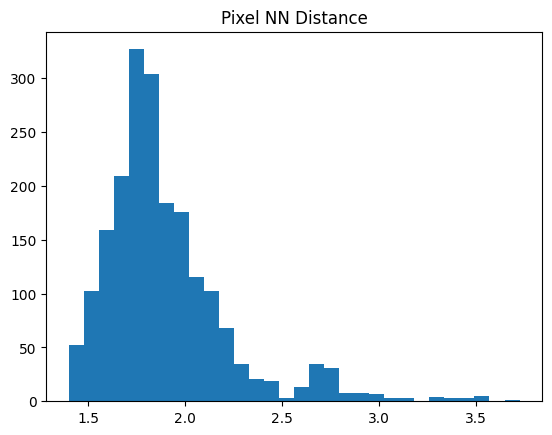

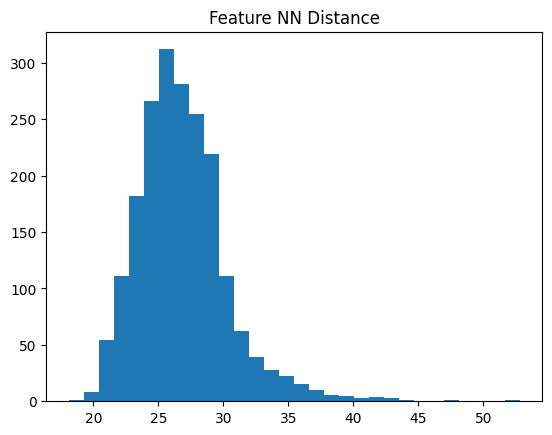

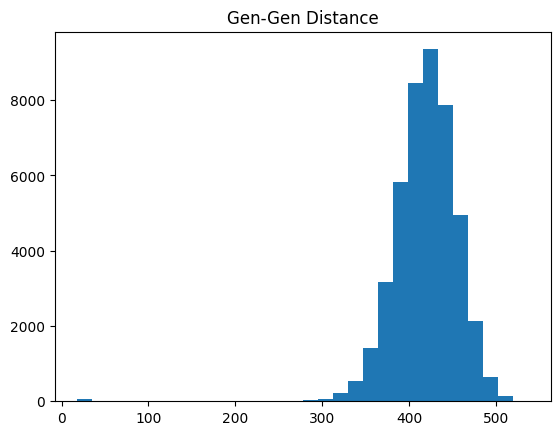

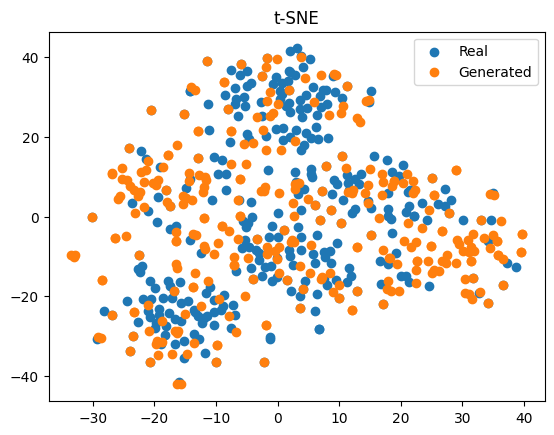

In [4]:
# ============================================================
# 🚀 FINAL MEMORY-SAFE + OPTIMIZED DIVERSITY VALIDATION
# ============================================================

import os, torch, numpy as np, matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from torchvision import transforms as T, models
from sklearn.manifold import TSNE

# ================= PATHS =================
REAL_DIR = "/content/drive/MyDrive/POTATODATASET/PLDDATASET/Healthy"
GEN_DIR  = "/content/drive/MyDrive/POTATODATASET/HealthyFOLD1_PL_LDGAN/generated_5000"

device = "cuda" if torch.cuda.is_available() else "cpu"

# ================= TRANSFORM =================
IMG_SIZE = 128   # 🔥 reduced for memory safety
tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor()
])

# ================= LOAD =================
def load_images(folder):
    return [os.path.join(folder,f) for f in os.listdir(folder)
            if f.lower().endswith(('.png','.jpg','.jpeg'))]

real_paths = load_images(REAL_DIR)
gen_paths  = load_images(GEN_DIR)

# 👉 Optional (recommended for speed)
gen_paths  = gen_paths[:2000]
real_paths = real_paths[:2000]

print("Real:", len(real_paths))
print("Generated:", len(gen_paths))

# ============================================================
# 🚀 FEATURE EXTRACTOR (BATCHED)
# ============================================================

vgg = models.vgg16(pretrained=True).features[:23].to(device).eval()
for p in vgg.parameters(): p.requires_grad=False

def extract_features(paths, batch_size=32):
    feats = []
    for i in tqdm(range(0, len(paths), batch_size)):
        imgs = []
        for p in paths[i:i+batch_size]:
            imgs.append(tf(Image.open(p).convert("RGB")))

        imgs = torch.stack(imgs).to(device)

        with torch.no_grad():
            f = vgg(imgs).view(imgs.size(0), -1)

        feats.append(f.cpu().numpy())

    return np.vstack(feats).astype(np.float32)

print("🚀 Extracting features...")
real_feats = extract_features(real_paths)
gen_feats  = extract_features(gen_paths)

# ============================================================
# 🚀 FEATURE NN (SAFE)
# ============================================================

print("🚀 Feature NN (safe)...")

feature_nn = []

for g in tqdm(gen_feats):
    d = np.linalg.norm(real_feats - g, axis=1)
    feature_nn.append(d.min())

feature_nn = np.array(feature_nn)

# ============================================================
# 🚀 PIXEL NN (SAFE, NO MATRIX)
# ============================================================

print("🚀 Pixel NN (safe)...")

def get_pixel(img_path):
    return tf(Image.open(img_path).convert("RGB")).view(-1).numpy()

# Preload real pixels once
real_pixels = np.array([get_pixel(p) for p in tqdm(real_paths)])

pixel_nn = []

for g_path in tqdm(gen_paths):
    g = get_pixel(g_path)
    d = np.linalg.norm(real_pixels - g, axis=1)
    pixel_nn.append(d.min())

pixel_nn = np.array(pixel_nn)

# ============================================================
# 🚀 GEN-GEN DIVERSITY (SUBSET ONLY)
# ============================================================

print("🚀 Gen-Gen diversity...")

subset = min(300, len(gen_feats))
idx = np.random.choice(len(gen_feats), subset, replace=False)

sub = gen_feats[idx]

gen_gen_dist = []

for i in range(subset):
    d = np.linalg.norm(sub - sub[i], axis=1)
    gen_gen_dist.extend(d[i+1:])

gen_gen_dist = np.array(gen_gen_dist)

# ============================================================
# 🚀 VARIANCE + ICV
# ============================================================

real_var = np.var(real_feats, axis=0).mean()
gen_var  = np.var(gen_feats, axis=0).mean()

def icv(feats):
    c = feats.mean(axis=0)
    return np.mean(np.linalg.norm(feats - c, axis=1))

real_icv = icv(real_feats)
gen_icv  = icv(gen_feats)

# ============================================================
# 🚀 RESULTS
# ============================================================

print("\n📊 ===== FINAL RESULTS =====")
print("Pixel Mean:", pixel_nn.mean())
print("Feature Mean:", feature_nn.mean())
print("Gen-Gen Mean:", gen_gen_dist.mean())

print("\nVariance -> Real:", real_var, "| Gen:", gen_var)
print("ICV -> Real:", real_icv, "| Gen:", gen_icv)

# ============================================================
# 🚀 PLOTS
# ============================================================

plt.figure()
plt.hist(pixel_nn, bins=30)
plt.title("Pixel NN Distance")
plt.savefig("pixel_hist.png")

plt.figure()
plt.hist(feature_nn, bins=30)
plt.title("Feature NN Distance")
plt.savefig("feature_hist.png")

plt.figure()
plt.hist(gen_gen_dist, bins=30)
plt.title("Gen-Gen Distance")
plt.savefig("gengen_hist.png")

# ============================================================
# 🚀 t-SNE
# ============================================================

print("🚀 Running t-SNE...")

sample_n = min(300, len(real_feats), len(gen_feats))

combined = np.vstack([real_feats[:sample_n], gen_feats[:sample_n]])

tsne = TSNE(n_components=2, random_state=42)
emb = tsne.fit_transform(combined)

plt.figure()
plt.scatter(emb[:sample_n,0], emb[:sample_n,1], label="Real")
plt.scatter(emb[sample_n:,0], emb[sample_n:,1], label="Generated")
plt.legend()
plt.title("t-SNE")
plt.savefig("tsne.png")

print("\n✅ SAFE + OPTIMIZED VALIDATION COMPLETE")

In [2]:
# ============================================================
# 🚀 PL-LDGAN FOLD-1 TRAINING LATEBLIGHT (FINAL + NO LEAKAGE)
# ============================================================

import os, torch, numpy as np
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T, models
from torchvision.utils import save_image
from PIL import Image
import torch.nn.functional as F
from sklearn.model_selection import StratifiedKFold
from tqdm import tqdm

# ================= PATH =================
ROOT = "/content/drive/MyDrive/POTATODATASET/PLDDATASET"
OUT = "/content/drive/MyDrive/POTATODATASET/LBFOLD1_PL_LDGAN"

SAMPLE_DIR = os.path.join(OUT, "samples")
CKPT_DIR = os.path.join(OUT, "checkpoints")

os.makedirs(SAMPLE_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

# ================= CONFIG =================
IMG_SIZE = 256
LATENT_CH = 128
BATCH = 8
TIMESTEPS = 200
EPOCHS = 100
LR = 2e-4

device = "cuda" if torch.cuda.is_available() else "cpu"

# ================= LOAD DATA =================
def load_paths_labels(root):
    paths, labels = [], []
    classes = sorted(os.listdir(root))

    for idx, cls in enumerate(classes):
        cls_path = os.path.join(root, cls)
        for f in os.listdir(cls_path):
            if f.lower().endswith(('.png','.jpg','.jpeg')):
                paths.append(os.path.join(cls_path, f))
                labels.append(idx)

    return np.array(paths), np.array(labels), classes

ALL_PATHS, ALL_LABELS, CLASS_NAMES = load_paths_labels(ROOT)

# ================= FOLD-1 =================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, val_idx = list(skf.split(ALL_PATHS, ALL_LABELS))[0]

TARGET_CLASS_NAME = "LateBlight"
TARGET_CLASS = CLASS_NAMES.index(TARGET_CLASS_NAME)

train_paths = ALL_PATHS[train_idx]
train_labels = ALL_LABELS[train_idx]

fold_train_paths = train_paths[train_labels == TARGET_CLASS]

print("Training class:", TARGET_CLASS_NAME)
print("Fold-1 samples:", len(fold_train_paths))

# ================= DATASET =================
class LeafDataset(Dataset):
    def __init__(self, paths):
        self.paths = paths
        self.tf = T.Compose([
            T.Resize((IMG_SIZE,IMG_SIZE)),
            T.ToTensor(),
            T.Normalize([0.5]*3,[0.5]*3)
        ])

    def __len__(self): return len(self.paths)

    def __getitem__(self,i):
        return self.tf(Image.open(self.paths[i]).convert("RGB"))

loader = DataLoader(LeafDataset(fold_train_paths),
                    batch_size=BATCH,
                    shuffle=True,
                    num_workers=2,
                    pin_memory=True)

# ================= MODEL =================
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,64,4,2,1)
        self.conv2 = nn.Conv2d(64,128,4,2,1)
        self.conv3 = nn.Conv2d(128,LATENT_CH,3,1,1)

    def forward(self,x):
        x1 = F.relu(self.conv1(x))
        x2 = F.relu(self.conv2(x1))
        z  = F.relu(self.conv3(x2))
        return z, x1, x2

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_latent = nn.Sequential(
            nn.Conv2d(LATENT_CH+128,128,3,1,1),
            nn.BatchNorm2d(128), nn.ReLU()
        )

        self.up1 = nn.ConvTranspose2d(128,64,4,2,1)

        self.conv1 = nn.Sequential(
            nn.Conv2d(64+64,64,3,1,1),
            nn.BatchNorm2d(64), nn.ReLU()
        )

        self.up2 = nn.ConvTranspose2d(64,32,4,2,1)

        self.refine = nn.Sequential(
            nn.Conv2d(32,32,3,1,1),
            nn.ReLU(),
            nn.Conv2d(32,3,3,1,1)
        )

    def forward(self,z,x1,x2):
        x = torch.cat([z,x2],1)
        x = self.conv_latent(x)
        x = self.up1(x)
        x = torch.cat([x,x1],1)
        x = self.conv1(x)
        x = self.up2(x)
        return torch.tanh(self.refine(x))

class LatentUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(TIMESTEPS, LATENT_CH)
        self.net = nn.Sequential(
            nn.Conv2d(LATENT_CH,LATENT_CH,3,1,1), nn.SiLU(),
            nn.Conv2d(LATENT_CH,LATENT_CH,3,1,1), nn.SiLU(),
            nn.Conv2d(LATENT_CH,LATENT_CH,3,1,1)
        )

    def forward(self,z,t):
        e = self.embed(t).view(-1,LATENT_CH,1,1)
        return self.net(z + e)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,32,4,2,1)
        self.conv2 = nn.Conv2d(32,64,4,2,1)
        self.conv3 = nn.Conv2d(64,128,4,2,1)
        self.out = nn.Conv2d(128,1,4,1,0)

    def forward(self,x):
        f1 = F.leaky_relu(self.conv1(x),0.2)
        f2 = F.leaky_relu(self.conv2(f1),0.2)
        f3 = F.leaky_relu(self.conv3(f2),0.2)
        out = self.out(f3)
        return out, [f1,f2,f3]

# ================= INIT =================
E, G, U, D = Encoder().to(device), Decoder().to(device), LatentUNet().to(device), Discriminator().to(device)

opt_G = optim.Adam(list(E.parameters())+list(G.parameters())+list(U.parameters()), lr=LR)
opt_D = optim.Adam(D.parameters(), lr=LR, betas=(0.5,0.999))

bce = nn.BCEWithLogitsLoss()

# ================= PERCEPTUAL =================
vgg = models.vgg16(pretrained=True).features[:23].to(device).eval()
for p in vgg.parameters(): p.requires_grad=False

def perceptual(x,y):
    return F.l1_loss(vgg((x+1)/2), vgg((y+1)/2))

# ================= DIFFUSION =================
betas = torch.linspace(1e-4,0.02,TIMESTEPS).to(device)
alphas = 1 - betas
alpha_hat = torch.cumprod(alphas,0)

# ================= TRAIN =================
print("🚀 Training Fold-1 PL-LDGAN")

for epoch in range(EPOCHS):
    for imgs in tqdm(loader):
        imgs = imgs.to(device)

        z,x1,x2 = E(imgs)
        recon = G(z,x1,x2)

        # ===== LOSSES =====
        ae = F.mse_loss(recon,imgs)
        perc = perceptual(recon,imgs)

        t = torch.randint(0,TIMESTEPS,(z.size(0),),device=device)
        noise = torch.randn_like(z)
        a = alpha_hat[t].view(-1,1,1,1)
        z_noisy = torch.sqrt(a)*z + torch.sqrt(1-a)*noise

        diff = F.mse_loss(U(z_noisy,t), noise)

        pred_fake, feat_fake = D(recon)
        pred_real, feat_real = D(imgs)

        gan = bce(pred_fake, torch.ones_like(pred_fake))

        fm = sum(F.l1_loss(f_fake, f_real.detach()) for f_fake,f_real in zip(feat_fake,feat_real))

        g_loss = 0.8*ae + 0.3*diff + 0.25*gan + 0.25*perc + 0.1*fm

        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()

        # ===== DISCRIMINATOR =====
        d_loss = 0.5*(bce(pred_real, torch.ones_like(pred_real)) +
                      bce(pred_fake.detach(), torch.zeros_like(pred_fake)))

        opt_D.zero_grad()
        d_loss.backward()
        opt_D.step()

    print(f"Epoch {epoch+1} | AE {ae:.3f} Diff {diff:.3f} GAN {gan:.3f}")

    # ===== SAVE SAMPLES =====
    if (epoch+1)%10==0:
        save_image((recon[:8]+1)/2, f"{SAMPLE_DIR}/epoch_{epoch+1}.png", nrow=4)

    # ===== SAVE CHECKPOINT =====
    if (epoch+1)%20==0:
        torch.save({
            "E":E.state_dict(),
            "G":G.state_dict(),
            "U":U.state_dict(),
            "D":D.state_dict()
        }, f"{CKPT_DIR}/model_epoch_{epoch+1}.pt")

print("✅ Training Complete")

Training class: LateBlight
Fold-1 samples: 1139


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 237MB/s]


🚀 Training Fold-1 PL-LDGAN


...

Epoch 98 | AE 0.001 Diff 0.207 GAN 0.000


100%|██████████| 143/143 [00:04<00:00, 29.58it/s]


Epoch 99 | AE 0.001 Diff 0.329 GAN 0.000


100%|██████████| 143/143 [00:04<00:00, 29.42it/s]


Epoch 100 | AE 0.001 Diff 0.679 GAN 0.000
✅ Training Complete


In [3]:
# ============================================================
# 🚀 GENERATE 5000  LATEBLIGHT IMAGES ( - FOLD1)
# ============================================================

import os, torch, zipfile, random
from torch import nn
from torchvision import transforms as T
from torchvision.utils import save_image
from PIL import Image
from tqdm import tqdm

# ================= PATH =================
CHECKPOINT_PATH = "/content/drive/MyDrive/POTATODATASET/LBFOLD1_PL_LDGAN/checkpoints/model_epoch_100.pt"

# 👉 IMPORTANT: same class folder used in Fold-1 training
DATASET_PATH = "/content/drive/MyDrive/POTATODATASET/PLDDATASET/LateBlight"

OUT_DIR = "/content/drive/MyDrive/POTATODATASET/LBFOLD1_PL_LDGAN/generated_5000"
ZIP_PATH = "/content/drive/MyDrive/POTATODATASET/LBFOLD1_PL_LDGAN/generated_5000.zip"

os.makedirs(OUT_DIR, exist_ok=True)

# ================= CONFIG =================
IMG_SIZE = 256
LATENT_CH = 128
TOTAL_IMAGES = 5000
NOISE_STRENGTH = 0.12   # 🔥 best range: 0.1–0.15

device = "cuda" if torch.cuda.is_available() else "cpu"

# ================= TRANSFORM =================
tf = T.Compose([
    T.Resize((IMG_SIZE,IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.5]*3,[0.5]*3)
])

# ================= LOAD IMAGE PATHS =================
img_files = [os.path.join(DATASET_PATH,f)
             for f in os.listdir(DATASET_PATH)
             if f.lower().endswith(('.png','.jpg','.jpeg'))]

print(f"✅ Real images loaded: {len(img_files)}")

# ================= MODEL =================
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,64,4,2,1)
        self.conv2 = nn.Conv2d(64,128,4,2,1)
        self.conv3 = nn.Conv2d(128,LATENT_CH,3,1,1)

    def forward(self,x):
        x1 = torch.relu(self.conv1(x))
        x2 = torch.relu(self.conv2(x1))
        z  = torch.relu(self.conv3(x2))
        return z, x1, x2

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_latent = nn.Sequential(
            nn.Conv2d(LATENT_CH+128,128,3,1,1),
            nn.BatchNorm2d(128), nn.ReLU()
        )

        self.up1 = nn.ConvTranspose2d(128,64,4,2,1)

        self.conv1 = nn.Sequential(
            nn.Conv2d(64+64,64,3,1,1),
            nn.BatchNorm2d(64), nn.ReLU()
        )

        self.up2 = nn.ConvTranspose2d(64,32,4,2,1)

        self.refine = nn.Sequential(
            nn.Conv2d(32,32,3,1,1),
            nn.ReLU(),
            nn.Conv2d(32,3,3,1,1)
        )

    def forward(self,z,x1,x2):
        x = torch.cat([z,x2],1)
        x = self.conv_latent(x)

        x = self.up1(x)
        x = torch.cat([x,x1],1)
        x = self.conv1(x)

        x = self.up2(x)
        return torch.tanh(self.refine(x))

# ================= LOAD MODEL =================
E = Encoder().to(device)
G = Decoder().to(device)

ckpt = torch.load(CHECKPOINT_PATH, map_location=device)

print("Checkpoint keys:", ckpt.keys())

E.load_state_dict(ckpt["E"])
G.load_state_dict(ckpt["G"])

E.eval(); G.eval()
print("✅ Model Loaded")

# ================= GENERATION =================
print("🚀 Generating images...")

for i in tqdm(range(TOTAL_IMAGES)):

    # pick random real image
    img_path = random.choice(img_files)

    img = Image.open(img_path).convert("RGB")
    img = tf(img).unsqueeze(0).to(device)

    with torch.no_grad():
        z,x1,x2 = E(img)

        # 🔥 KEY: latent perturbation
        noise = torch.randn_like(z) * NOISE_STRENGTH
        z = z + noise

        fake = G(z,x1,x2)

    save_image((fake[0]+1)/2,
               f"{OUT_DIR}/img_{i:05d}.png")

print("✅ 5000 images generated")

# ================= ZIP =================
print("📦 Creating ZIP...")

with zipfile.ZipFile(ZIP_PATH,'w',zipfile.ZIP_DEFLATED) as zf:
    for f in os.listdir(OUT_DIR):
        zf.write(os.path.join(OUT_DIR,f), f)

print(f"✅ ZIP saved at: {ZIP_PATH}")

✅ Real images loaded: 1424
Checkpoint keys: dict_keys(['E', 'G', 'U', 'D'])
✅ Model Loaded
🚀 Generating images...


100%|██████████| 5000/5000 [04:04<00:00, 20.48it/s]


✅ 5000 images generated
📦 Creating ZIP...
✅ ZIP saved at: /content/drive/MyDrive/POTATODATASET/LBFOLD1_PL_LDGAN/generated_5000.zip


Real: 1424
Generated: 2000


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


🚀 Extracting features...


100%|██████████| 63/63 [00:13<00:00,  4.79it/s]


🚀 Feature NN (safe)...


100%|██████████| 2000/2000 [18:28<00:00,  1.80it/s]


🚀 Pixel NN (safe)...


100%|██████████| 2000/2000 [05:37<00:00,  5.92it/s]


🚀 Gen-Gen diversity...

📊 ===== FINAL RESULTS =====
Pixel Mean: 1.7629153
Feature Mean: 28.121168
Gen-Gen Mean: 465.83292

Variance -> Real: 0.8198282 | Gen: 0.81568724
ICV -> Real: 326.8373 | Gen: 325.972
🚀 Running t-SNE...

✅ SAFE + OPTIMIZED VALIDATION COMPLETE


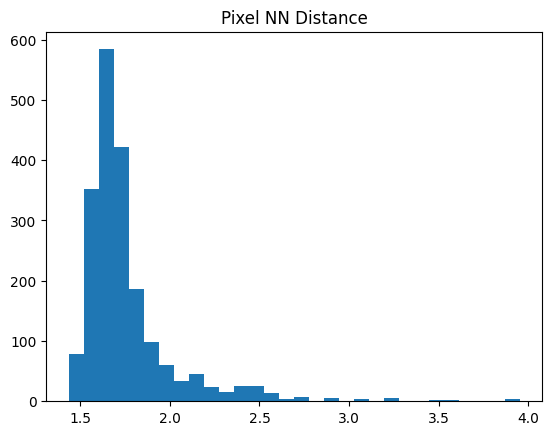

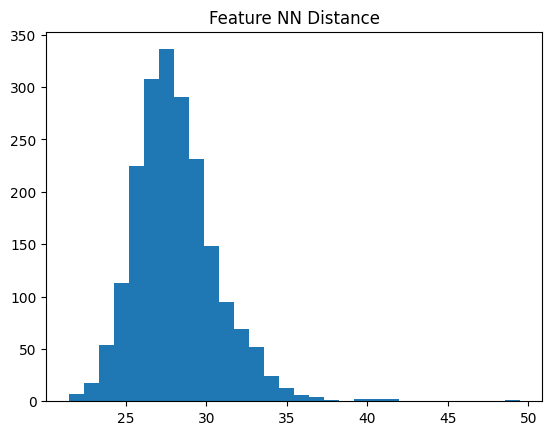

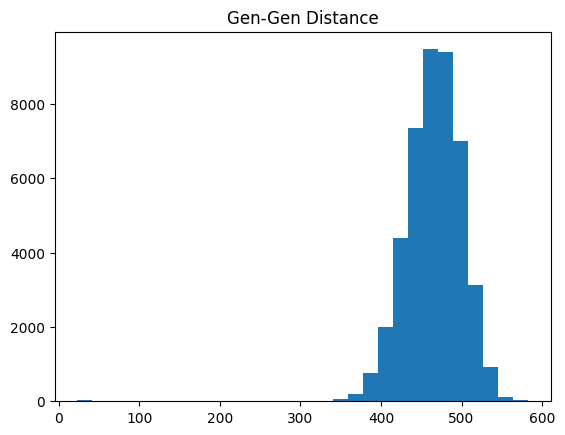

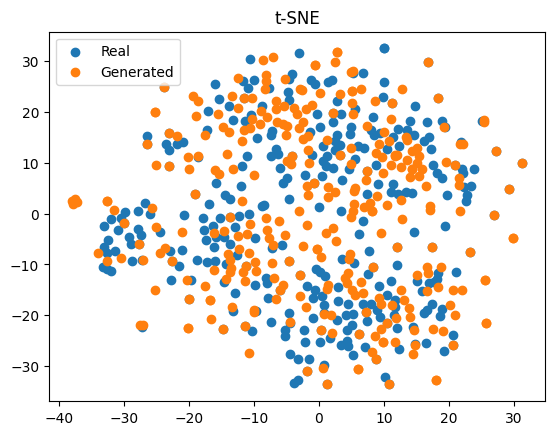

In [5]:
# ============================================================
# 🚀 FINAL MEMORY-SAFE + OPTIMIZED DIVERSITY VALIDATION
# ============================================================

import os, torch, numpy as np, matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from torchvision import transforms as T, models
from sklearn.manifold import TSNE

# ================= PATHS =================
REAL_DIR = "/content/drive/MyDrive/POTATODATASET/PLDDATASET/LateBlight"
GEN_DIR  = "/content/drive/MyDrive/POTATODATASET/LBFOLD1_PL_LDGAN/generated_5000"

device = "cuda" if torch.cuda.is_available() else "cpu"

# ================= TRANSFORM =================
IMG_SIZE = 128   # 🔥 reduced for memory safety
tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor()
])

# ================= LOAD =================
def load_images(folder):
    return [os.path.join(folder,f) for f in os.listdir(folder)
            if f.lower().endswith(('.png','.jpg','.jpeg'))]

real_paths = load_images(REAL_DIR)
gen_paths  = load_images(GEN_DIR)

# 👉 Optional (recommended for speed)
gen_paths  = gen_paths[:2000]
real_paths = real_paths[:2000]

print("Real:", len(real_paths))
print("Generated:", len(gen_paths))

# ============================================================
# 🚀 FEATURE EXTRACTOR (BATCHED)
# ============================================================

vgg = models.vgg16(pretrained=True).features[:23].to(device).eval()
for p in vgg.parameters(): p.requires_grad=False

def extract_features(paths, batch_size=32):
    feats = []
    for i in tqdm(range(0, len(paths), batch_size)):
        imgs = []
        for p in paths[i:i+batch_size]:
            imgs.append(tf(Image.open(p).convert("RGB")))

        imgs = torch.stack(imgs).to(device)

        with torch.no_grad():
            f = vgg(imgs).view(imgs.size(0), -1)

        feats.append(f.cpu().numpy())

    return np.vstack(feats).astype(np.float32)

print("🚀 Extracting features...")
real_feats = extract_features(real_paths)
gen_feats  = extract_features(gen_paths)

# ============================================================
# 🚀 FEATURE NN (SAFE)
# ============================================================

print("🚀 Feature NN (safe)...")

feature_nn = []

for g in tqdm(gen_feats):
    d = np.linalg.norm(real_feats - g, axis=1)
    feature_nn.append(d.min())

feature_nn = np.array(feature_nn)

# ============================================================
# 🚀 PIXEL NN (SAFE, NO MATRIX)
# ============================================================

print("🚀 Pixel NN (safe)...")

def get_pixel(img_path):
    return tf(Image.open(img_path).convert("RGB")).view(-1).numpy()

# Preload real pixels once
real_pixels = np.array([get_pixel(p) for p in tqdm(real_paths)])

pixel_nn = []

for g_path in tqdm(gen_paths):
    g = get_pixel(g_path)
    d = np.linalg.norm(real_pixels - g, axis=1)
    pixel_nn.append(d.min())

pixel_nn = np.array(pixel_nn)

# ============================================================
# 🚀 GEN-GEN DIVERSITY (SUBSET ONLY)
# ============================================================

print("🚀 Gen-Gen diversity...")

subset = min(300, len(gen_feats))
idx = np.random.choice(len(gen_feats), subset, replace=False)

sub = gen_feats[idx]

gen_gen_dist = []

for i in range(subset):
    d = np.linalg.norm(sub - sub[i], axis=1)
    gen_gen_dist.extend(d[i+1:])

gen_gen_dist = np.array(gen_gen_dist)

# ============================================================
# 🚀 VARIANCE + ICV
# ============================================================

real_var = np.var(real_feats, axis=0).mean()
gen_var  = np.var(gen_feats, axis=0).mean()

def icv(feats):
    c = feats.mean(axis=0)
    return np.mean(np.linalg.norm(feats - c, axis=1))

real_icv = icv(real_feats)
gen_icv  = icv(gen_feats)

# ============================================================
# 🚀 RESULTS
# ============================================================

print("\n📊 ===== FINAL RESULTS =====")
print("Pixel Mean:", pixel_nn.mean())
print("Feature Mean:", feature_nn.mean())
print("Gen-Gen Mean:", gen_gen_dist.mean())

print("\nVariance -> Real:", real_var, "| Gen:", gen_var)
print("ICV -> Real:", real_icv, "| Gen:", gen_icv)

# ============================================================
# 🚀 PLOTS
# ============================================================

plt.figure()
plt.hist(pixel_nn, bins=30)
plt.title("Pixel NN Distance")
plt.savefig("pixel_hist.png")

plt.figure()
plt.hist(feature_nn, bins=30)
plt.title("Feature NN Distance")
plt.savefig("feature_hist.png")

plt.figure()
plt.hist(gen_gen_dist, bins=30)
plt.title("Gen-Gen Distance")
plt.savefig("gengen_hist.png")

# ============================================================
# 🚀 t-SNE
# ============================================================

print("🚀 Running t-SNE...")

sample_n = min(300, len(real_feats), len(gen_feats))

combined = np.vstack([real_feats[:sample_n], gen_feats[:sample_n]])

tsne = TSNE(n_components=2, random_state=42)
emb = tsne.fit_transform(combined)

plt.figure()
plt.scatter(emb[:sample_n,0], emb[:sample_n,1], label="Real")
plt.scatter(emb[sample_n:,0], emb[sample_n:,1], label="Generated")
plt.legend()
plt.title("t-SNE")
plt.savefig("tsne.png")

print("\n✅ SAFE + OPTIMIZED VALIDATION COMPLETE")